In [71]:
import pandas as pd
df = pd.read_csv("E Commerce Dataset.csv")

In [72]:
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# ADVANCED FEATURE ENGINEERING  (built strictly from raw original columns)
# Raw columns used:
#   Tenure, CityTier, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered,
#   SatisfactionScore, NumberOfAddress, Complain, OrderAmountHikeFromlastYear,
#   CouponUsed, OrderCount, DaySinceLastOrder, CashbackAmount,
#   PreferredLoginDevice, PreferredPaymentMode, Gender,
#   PreferedOrderCat, MaritalStatus
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("ADVANCED FEATURE ENGINEERING FROM RAW COLUMNS")
print("=" * 70)

df_fe = df.copy()

# ── helper: safe divide ──────────────────────────────────────────────────────
def safe_div(a, b, fill=0.0):
    return np.where(b != 0, a / b, fill)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 1 · RFM-STYLE FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("\n[1] RFM-style features...")

# Recency – normalised days since last order relative to tenure
df_fe['Recency_Score']         = safe_div(df_fe['DaySinceLastOrder'],
                                          df_fe['Tenure'] + 1)

# Frequency – orders per active month
df_fe['Order_Frequency']       = safe_div(df_fe['OrderCount'],
                                          df_fe['Tenure'] + 1)

# Monetary – cashback earned per order (proxy for spend value)
df_fe['Cashback_per_Order']    = safe_div(df_fe['CashbackAmount'],
                                          df_fe['OrderCount'] + 1)

# Monetary – coupon spend per order
df_fe['Coupon_per_Order']      = safe_div(df_fe['CouponUsed'],
                                          df_fe['OrderCount'] + 1)

# Monetary – avg order amount hike per order
df_fe['AvgHike_per_Order']     = safe_div(df_fe['OrderAmountHikeFromlastYear'],
                                          df_fe['OrderCount'] + 1)

# Recency bins  (higher bin number = longer away = higher risk)
df_fe['Recency_Bin'] = pd.cut(
    df_fe['DaySinceLastOrder'],
    bins=[-1, 5, 15, 30, 9999],
    labels=[0, 1, 2, 3]
).astype(float)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 2 · TENURE / LIFECYCLE FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[2] Tenure / lifecycle features...")

# Lifecycle stage: 0=New(≤1m), 1=Growing(2-6m), 2=Mature(7-12m), 3=Loyal(>12m)
df_fe['Lifecycle_Stage'] = pd.cut(
    df_fe['Tenure'],
    bins=[-1, 1, 6, 12, 9999],
    labels=[0, 1, 2, 3]
).astype(float)

# Squared tenure – captures accelerating loyalty effect
df_fe['Tenure_sq']             = df_fe['Tenure'] ** 2

# App engagement density (hours per active month)
df_fe['App_Hours_per_Month']   = safe_div(df_fe['HourSpendOnApp'],
                                          df_fe['Tenure'] + 1)

# Address churn velocity (new addresses relative to tenure = instability signal)
df_fe['Address_per_Month']     = safe_div(df_fe['NumberOfAddress'],
                                          df_fe['Tenure'] + 1)

# Device expansion rate
df_fe['Device_per_Month']      = safe_div(df_fe['NumberOfDeviceRegistered'],
                                          df_fe['Tenure'] + 1)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 3 · SATISFACTION & COMPLAINT FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[3] Satisfaction & complaint features...")

# Inverse satisfaction (so higher = worse)
df_fe['Inv_Satisfaction']      = 6 - df_fe['SatisfactionScore']

# Satisfaction squared – captures extreme low scores more sharply
df_fe['Satisfaction_sq']       = df_fe['SatisfactionScore'] ** 2

# Complaint × inverse satisfaction = weighted severity
df_fe['Complaint_Severity']    = df_fe['Complain'] * df_fe['Inv_Satisfaction']

# Satisfaction decay over tenure (unhappy long-term customer = high risk)
df_fe['Satisfaction_Decay']    = safe_div(df_fe['Inv_Satisfaction'],
                                          df_fe['Tenure'] + 1)

# Chronic dissatisfaction flag: complained AND score ≤ 2
df_fe['Chronic_Dissatisfaction'] = (
    (df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] <= 2)
).astype(int)

# High risk flag: complained AND score ≤ 3
df_fe['High_Risk_Flag']        = (
    (df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] <= 3)
).astype(int)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 4 · ENGAGEMENT COMPOSITE FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[4] Engagement composite features...")

# Normalise three engagement signals to [0,1] then average
_h  = df_fe['HourSpendOnApp']  / (df_fe['HourSpendOnApp'].max()  + 1e-9)
_oc = df_fe['OrderCount']      / (df_fe['OrderCount'].max()      + 1e-9)
_cu = df_fe['CouponUsed']      / (df_fe['CouponUsed'].max()      + 1e-9)
df_fe['Engagement_Score']      = (_h + _oc + _cu) / 3.0 * 100

# Low engagement flag
df_fe['Low_Engagement_Flag']   = (df_fe['Order_Frequency'] < 1).astype(int)

# Tenure × OrderCount interaction (loyal + frequent = very sticky)
df_fe['Tenure_x_OrderCount']   = df_fe['Tenure'] * df_fe['OrderCount']

# App hours × coupon use (engaged bargain hunters)
df_fe['App_x_Coupon']          = df_fe['HourSpendOnApp'] * df_fe['CouponUsed']

# Satisfaction × OrderCount (happy frequent buyers = low churn)
df_fe['Satisfaction_x_Orders'] = df_fe['SatisfactionScore'] * df_fe['OrderCount']

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 5 · DOMAIN-ENCODED RISK SCORES (ordinal risk from domain knowledge)
# ════════════════════════════════════════════════════════════════════════════
print("[5] Domain-encoded risk scores...")

# Payment mode risk: COD/Cash easiest to defect, card = committed
_pay_risk = {
    'Cash on Delivery': 3, 'COD': 3,
    'E wallet': 2, 'UPI': 2,
    'Debit Card': 1, 'Credit Card': 1, 'CC': 1,
}
df_fe['Payment_Risk']          = df_fe['PreferredPaymentMode'].map(_pay_risk).fillna(2).astype(int)

# Order category risk: mobile/electronics buyers churn more (easier to price-compare)
_cat_risk = {
    'Mobile': 3, 'Mobile Phone': 3,
    'Laptop & Accessory': 2, 'Others': 2,
    'Fashion': 1, 'Grocery': 1,
}
df_fe['Category_Risk']         = df_fe['PreferedOrderCat'].map(_cat_risk).fillna(2).astype(int)

# City tier risk: Tier 3 cities = newer market = less loyalty
df_fe['CityTier_Risk']         = df_fe['CityTier'].map({1: 1, 2: 2, 3: 3}).fillna(2).astype(int)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 6 · DISTANCE & DELIVERY FEATURES
# ════════════════════════════════════════════════════════════════════════════
print("[6] Distance & delivery features...")

# Log-transform warehouse distance (right-skewed)
df_fe['Log_WarehouseToHome']   = np.log1p(df_fe['WarehouseToHome'].clip(lower=0))

# Far warehouse flag (top quartile)
df_fe['Far_Warehouse']         = (
    df_fe['WarehouseToHome'] > df_fe['WarehouseToHome'].quantile(0.75)
).astype(int)

# Distance × inverse satisfaction (far + unhappy = highest dropout risk)
df_fe['Distance_x_Dissatisfaction'] = (
    df_fe['WarehouseToHome'] * df_fe['Inv_Satisfaction']
)

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 7 · LOG TRANSFORMS (reduce skewness for linear/DNN models)
# ════════════════════════════════════════════════════════════════════════════
print("[7] Log-transformed skewed numerics...")

for _col in ['CashbackAmount', 'OrderAmountHikeFromlastYear',
             'DaySinceLastOrder', 'NumberOfAddress',
             'CouponUsed', 'OrderCount']:
    df_fe[f'Log_{_col}'] = np.log1p(df_fe[_col].clip(lower=0))

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 8 · POLYNOMIAL FEATURES (capture curvature for linear models)
# ════════════════════════════════════════════════════════════════════════════
print("[8] Polynomial (squared) features...")

for _col in ['DaySinceLastOrder', 'CashbackAmount', 'WarehouseToHome']:
    df_fe[f'{_col}_sq'] = df_fe[_col] ** 2

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 9 · CASHBACK TIER (loyalty segmentation)
# ════════════════════════════════════════════════════════════════════════════
print("[9] Cashback loyalty tier...")

df_fe['Cashback_Tier'] = pd.cut(
    df_fe['CashbackAmount'],
    bins=[-1, 100, 175, 250, 99999],
    labels=['Low', 'Medium', 'High', 'Premium']
).astype(str)   # convert to str so OHE handles it cleanly

# ════════════════════════════════════════════════════════════════════════════
# BLOCK 10 · COMPOSITE CHURN RISK SCORE
#   Weighted sum of the strongest individual churn signals.
#   Gives linear models a near-ready predictor; also a useful tree feature.
# ════════════════════════════════════════════════════════════════════════════
print("[10] Composite churn risk score...")

_dsl_norm  = df_fe['DaySinceLastOrder'] / (df_fe['DaySinceLastOrder'].max() + 1e-9)
_ten_norm  = 1 - df_fe['Tenure'] / (df_fe['Tenure'].max() + 1e-9)
_cb_norm   = 1 - df_fe['CashbackAmount'] / (df_fe['CashbackAmount'].max() + 1e-9)

df_fe['Composite_Risk_Score'] = (
    df_fe['Complain']       * 3.0 +   # strongest predictor
    df_fe['Inv_Satisfaction']         +   # unhappy customer
    _dsl_norm                         +   # not ordered recently
    _ten_norm                         +   # short tenure
    _cb_norm                              # low cashback incentive
)

# ════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════════════
new_features = [c for c in df_fe.columns if c not in df.columns]
print(f"\n  {len(new_features)} new features created from raw columns:")
for _f in new_features:
    print(f"      • {_f}")

print(f"\nOriginal shape : {df.shape}")
print(f"Enhanced shape : {df_fe.shape}  (+{len(new_features)} features)")

df = df_fe.copy()


ADVANCED FEATURE ENGINEERING FROM RAW COLUMNS

[1] RFM-style features...
[2] Tenure / lifecycle features...
[3] Satisfaction & complaint features...
[4] Engagement composite features...
[5] Domain-encoded risk scores...
[6] Distance & delivery features...
[7] Log-transformed skewed numerics...
[8] Polynomial (squared) features...
[9] Cashback loyalty tier...
[10] Composite churn risk score...

  39 new features created from raw columns:
      • Recency_Score
      • Order_Frequency
      • Cashback_per_Order
      • Coupon_per_Order
      • AvgHike_per_Order
      • Recency_Bin
      • Lifecycle_Stage
      • Tenure_sq
      • App_Hours_per_Month
      • Address_per_Month
      • Device_per_Month
      • Inv_Satisfaction
      • Satisfaction_sq
      • Complaint_Severity
      • Satisfaction_Decay
      • Chronic_Dissatisfaction
      • High_Risk_Flag
      • Engagement_Score
      • Low_Engagement_Flag
      • Tenure_x_OrderCount
      • App_x_Coupon
      • Satisfaction_x_Orders
    

## Additional Feature Engineering

Building on the base features above, we add deeper domain-driven and statistical features that are known to improve churn model performance:
1. **Log-transformed features** — reduce skewness for linear models
2. **Polynomial / squared features** — capture non-linear effects of top predictors
3. **Cross-category target statistics** — churn-signal-aware category encodings (computed on train set only to avoid leakage here; at EDA stage we use full data)
4. **Composite churn risk score** — a single weighted signal combining the strongest predictors
5. **Satisfaction decay & complaint severity** — interaction depth beyond a simple flag
6. **Address instability & device diversity** signals
7. **Payment mode risk** — domain-encoded ordinal risk level


In [73]:
# All advanced feature engineering is handled in the cell above.
# This cell confirms the final dataframe state before preprocessing.
print(f"Final engineered dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nAll columns:")
for c in df.columns:
    print(f"  {c}  [{df[c].dtype}]")


Final engineered dataframe: 5,630 rows × 59 columns

All columns:
  CustomerID  [int64]
  Churn  [int64]
  Tenure  [float64]
  PreferredLoginDevice  [object]
  CityTier  [int64]
  WarehouseToHome  [float64]
  PreferredPaymentMode  [object]
  Gender  [object]
  HourSpendOnApp  [float64]
  NumberOfDeviceRegistered  [int64]
  PreferedOrderCat  [object]
  SatisfactionScore  [int64]
  MaritalStatus  [object]
  NumberOfAddress  [int64]
  Complain  [int64]
  OrderAmountHikeFromlastYear  [float64]
  CouponUsed  [float64]
  OrderCount  [float64]
  DaySinceLastOrder  [float64]
  CashbackAmount  [int64]
  Recency_Score  [float64]
  Order_Frequency  [float64]
  Cashback_per_Order  [float64]
  Coupon_per_Order  [float64]
  AvgHike_per_Order  [float64]
  Recency_Bin  [float64]
  Lifecycle_Stage  [float64]
  Tenure_sq  [float64]
  App_Hours_per_Month  [float64]
  Address_per_Month  [float64]
  Device_per_Month  [float64]
  Inv_Satisfaction  [int64]
  Satisfaction_sq  [int64]
  Complaint_Severity  [in

In [74]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)

from sklearn.inspection import permutation_importance

## 2. Load Dataset

In [75]:
# ─── Verify the engineered dataset is ready ───
# df was set to df_fe (engineered) at the end of the feature engineering cell.
# Do NOT re-load the raw CSV here — that would wipe out all engineered features!
print("=" * 80)
print("Verifying Engineered E-Commerce Data...")
print("=" * 80)

print(f" Dataset ready!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Display first few rows
print("First 5 rows of the dataset:")
df.head()

Verifying Engineered E-Commerce Data...
 Dataset ready!
Shape: 5,630 rows × 59 columns

First 5 rows of the dataset:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Recency_Score,Order_Frequency,Cashback_per_Order,Coupon_per_Order,AvgHike_per_Order,Recency_Bin,Lifecycle_Stage,Tenure_sq,App_Hours_per_Month,Address_per_Month,Device_per_Month,Inv_Satisfaction,Satisfaction_sq,Complaint_Severity,Satisfaction_Decay,Chronic_Dissatisfaction,High_Risk_Flag,Engagement_Score,Low_Engagement_Flag,Tenure_x_OrderCount,App_x_Coupon,Satisfaction_x_Orders,Payment_Risk,Category_Risk,CityTier_Risk,Log_WarehouseToHome,Far_Warehouse,Distance_x_Dissatisfaction,Log_CashbackAmount,Log_OrderAmountHikeFromlastYear,Log_DaySinceLastOrder,Log_NumberOfAddress,Log_CouponUsed,Log_OrderCount,DaySinceLastOrder_sq,CashbackAmount_sq,WarehouseToHome_sq,Cashback_Tier,Composite_Risk_Score
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160,1.0,0.2,80.0,0.5,5.5,0.0,1.0,16.0,0.6,1.8,0.6,4,4,4,0.8,1,1,24.166667,1,4.0,3.0,2.0,1,2,3,1.945910,0,24.0,5.081404,2.484907,1.791759,2.302585,0.693147,0.693147,25.0,25600,36.0,Medium,8.550814
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121,NaN,NaN,60.5,0.0,7.5,0.0,NaN,NaN,NaN,NaN,NaN,3,9,3,NaN,0,1,22.083333,0,NaN,0.0,3.0,2,3,1,2.197225,0,24.0,4.804021,2.772589,0.000000,2.079442,0.000000,0.693147,0.0,14641,64.0,Medium,NaN
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120,NaN,NaN,60.0,0.0,7.0,0.0,NaN,NaN,NaN,NaN,NaN,3,9,3,NaN,0,1,15.416667,0,NaN,0.0,3.0,1,3,1,3.433987,1,90.0,4.795791,2.708050,1.386294,1.945910,0.000000,0.693147,9.0,14400,900.0,Medium,NaN
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134,3.0,1.0,67.0,0.0,11.5,0.0,0.0,0.0,2.0,8.0,4.0,1,25,0,1.0,0,0,15.416667,0,0.0,0.0,5.0,1,2,3,2.772589,0,15.0,4.905275,3.178054,1.386294,2.197225,0.000000,0.693147,9.0,17956,225.0,Medium,2.652910
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130,3.0,1.0,65.0,0.5,5.5,0.0,0.0,0.0,NaN,3.0,3.0,1,25,0,1.0,0,0,NaN,0,0.0,NaN,5.0,1,3,1,2.564949,0,12.0,4.875197,2.484907,1.386294,1.386294,0.693147,0.693147,9.0,16900,144.0,Medium,2.665217


In [76]:

# ---------------------------
# 2) Basic EDA
# ---------------------------
print("\n--- Column types ---")
print(df.dtypes)

print("\n--- Missing values (%) ---")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(30))

# Target distribution
TARGET_COL = "Churn"
print("\n--- Target distribution ---")
print(df[TARGET_COL].value_counts(dropna=False))
print(df[TARGET_COL].value_counts(normalize=True).rename("proportion"))

# Quick numeric summary
num_cols_all = df.select_dtypes(include=["number"]).columns.tolist()
print("\n--- Numeric summary (selected) ---")
print(df[num_cols_all].describe().T.head(20))

# Optional: correlations with churn for numeric columns (rough signal check)
if TARGET_COL in num_cols_all:
    corr = df[num_cols_all].corr(numeric_only=True)[TARGET_COL].sort_values(ascending=False)
    print("\n--- Numeric correlations with churn (rough) ---")
    print(corr)


--- Column types ---
CustomerID                           int64
Churn                                int64
Tenure                             float64
PreferredLoginDevice                object
CityTier                             int64
WarehouseToHome                    float64
PreferredPaymentMode                object
Gender                              object
HourSpendOnApp                     float64
NumberOfDeviceRegistered             int64
PreferedOrderCat                    object
SatisfactionScore                    int64
MaritalStatus                       object
NumberOfAddress                      int64
Complain                             int64
OrderAmountHikeFromlastYear        float64
CouponUsed                         float64
OrderCount                         float64
DaySinceLastOrder                  float64
CashbackAmount                       int64
Recency_Score                      float64
Order_Frequency                    float64
Cashback_per_Order              

## Advanced Feature Engineering for Better Results

Creating interaction features and domain-specific metrics can significantly improve model performance. We'll add:
1. **RFM-style features** (Recency, Frequency, Monetary patterns)
2. **Interaction features** (combinations that reveal hidden patterns)
3. **Behavioral ratios** (engagement metrics)
4. **Aggregated statistics** (per-category patterns)

# Task
Preprocess the `df` dataset by completing initial EDA and visualizing distributions, handling missing values, encoding categorical features, scaling numerical features, and splitting the data into training and testing sets, to prepare it for training Gradient Boosting, Logistic Regression, and XGBoost models.

## Complete Initial EDA and Visualize Distributions

### Subtask:
Building upon the existing EDA, generate visualizations such as histograms for numerical features, bar plots for categorical features, and explore relationships with the 'Churn' target variable using count plots or box plots. Ensure legends are provided for all plots.


**Reasoning**:
The first step is to import the necessary visualization libraries, `matplotlib.pyplot` and `seaborn`, to create the required plots.



In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries matplotlib.pyplot and seaborn imported successfully.")

Libraries matplotlib.pyplot and seaborn imported successfully.


In [78]:
TARGET_COL = 'Churn'
CUSTOMER_ID_COL = 'CustomerID'

# Identify numerical columns, excluding CustomerID and Churn
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in [TARGET_COL, CUSTOMER_ID_COL]]

# Identify categorical columns: both object and pandas Categorical dtype
# (pd.cut / pd.qcut produce 'category' dtype, not 'object')
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Convert any pandas Categorical columns to string so they behave like object columns
# in downstream imputation and encoding steps
for col in categorical_cols:
    if df[col].dtype.name == 'category':
        df[col] = df[col].astype(str)

print(f"Numerical columns (excluding '{TARGET_COL}' and '{CUSTOMER_ID_COL}'): {numerical_cols}")
print(f"Categorical columns (object + category): {categorical_cols}")


Numerical columns (excluding 'Churn' and 'CustomerID'): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Recency_Score', 'Order_Frequency', 'Cashback_per_Order', 'Coupon_per_Order', 'AvgHike_per_Order', 'Recency_Bin', 'Lifecycle_Stage', 'Tenure_sq', 'App_Hours_per_Month', 'Address_per_Month', 'Device_per_Month', 'Inv_Satisfaction', 'Satisfaction_sq', 'Complaint_Severity', 'Satisfaction_Decay', 'Chronic_Dissatisfaction', 'High_Risk_Flag', 'Engagement_Score', 'Low_Engagement_Flag', 'Tenure_x_OrderCount', 'App_x_Coupon', 'Satisfaction_x_Orders', 'Payment_Risk', 'Category_Risk', 'CityTier_Risk', 'Log_WarehouseToHome', 'Far_Warehouse', 'Distance_x_Dissatisfaction', 'Log_CashbackAmount', 'Log_OrderAmountHikeFromlastYear', 'Log_DaySinceLastOrder', 'Log_NumberOfAddress', 'Log_CouponUsed', 'Log_OrderCount', 

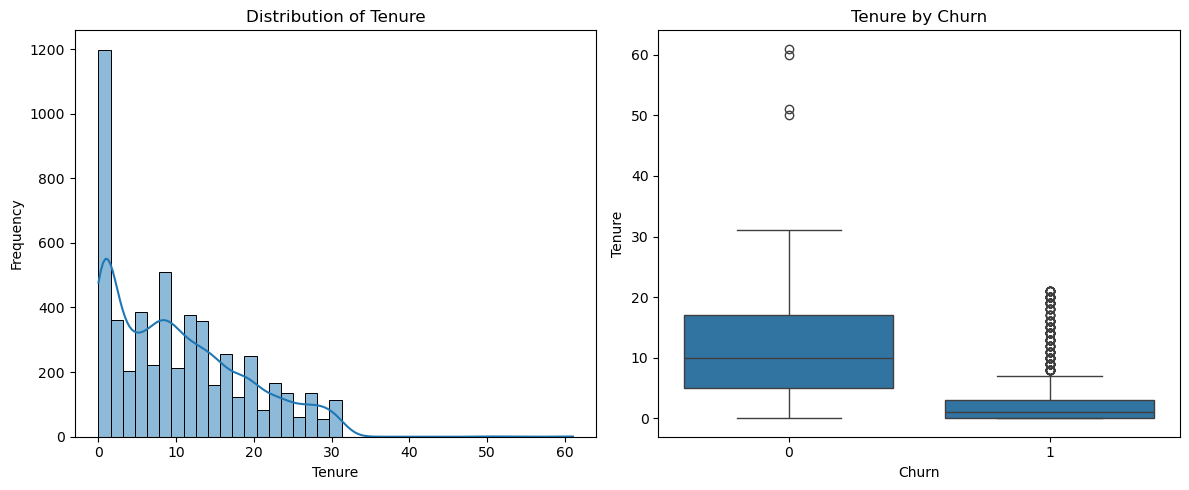

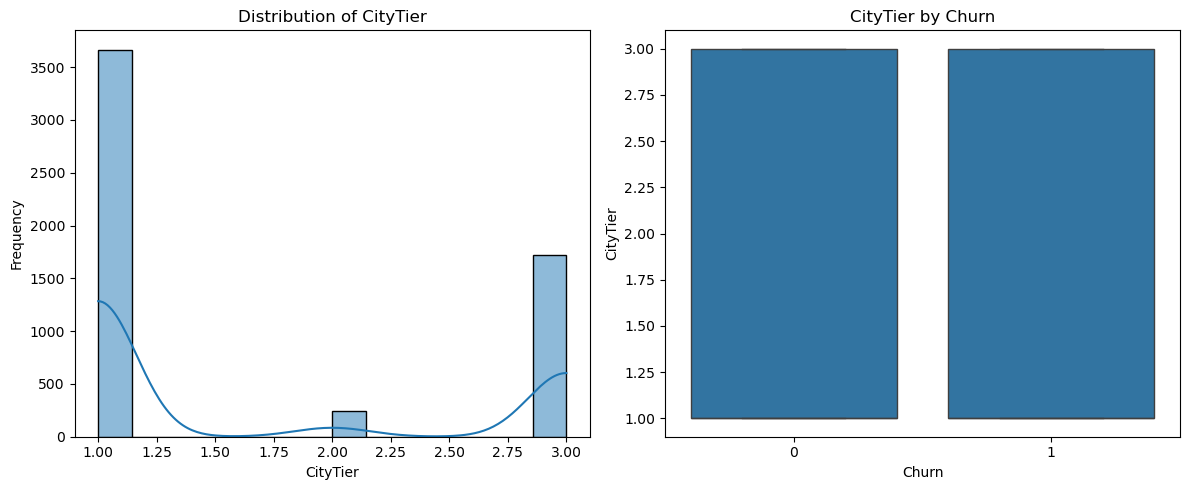

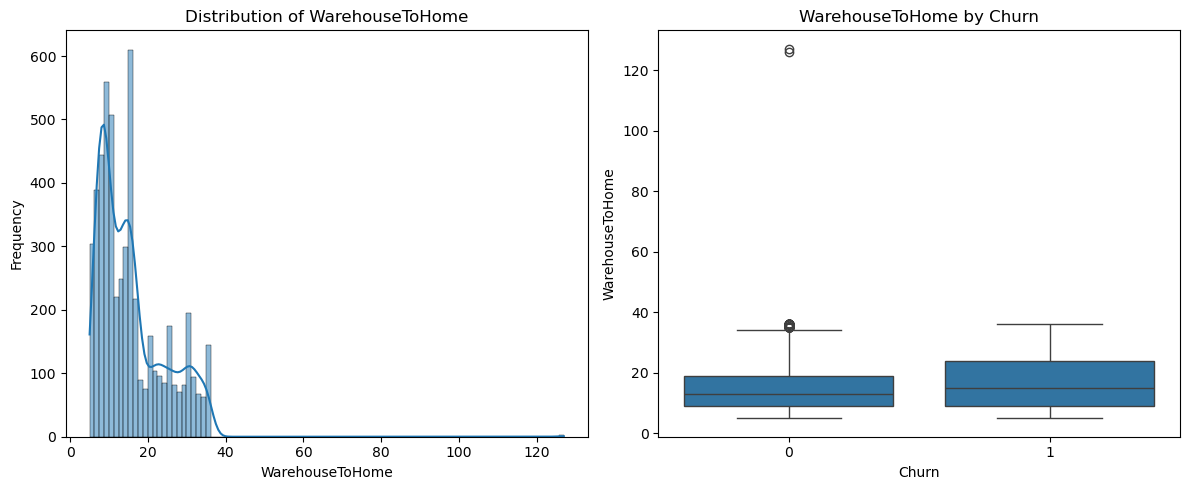

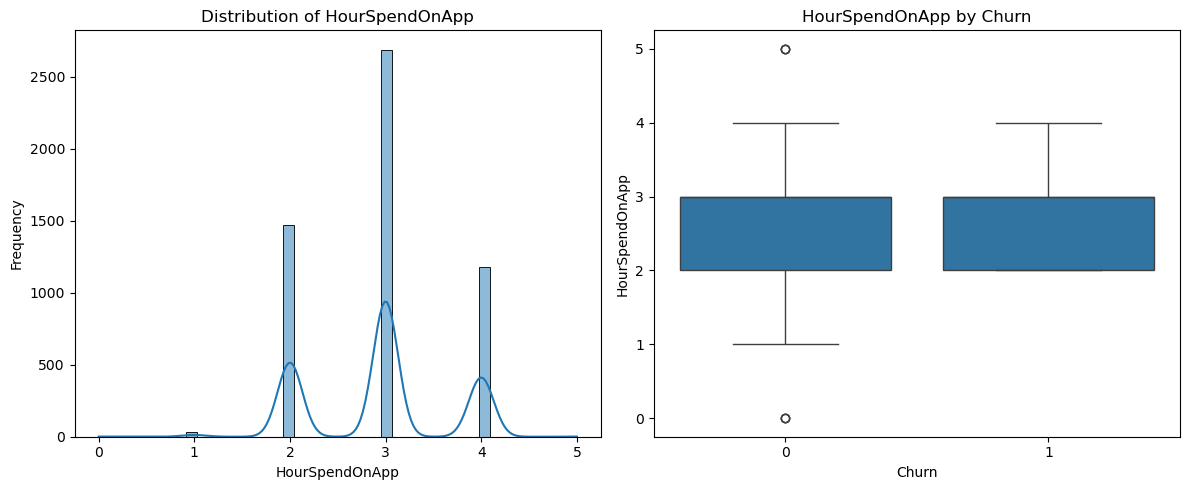

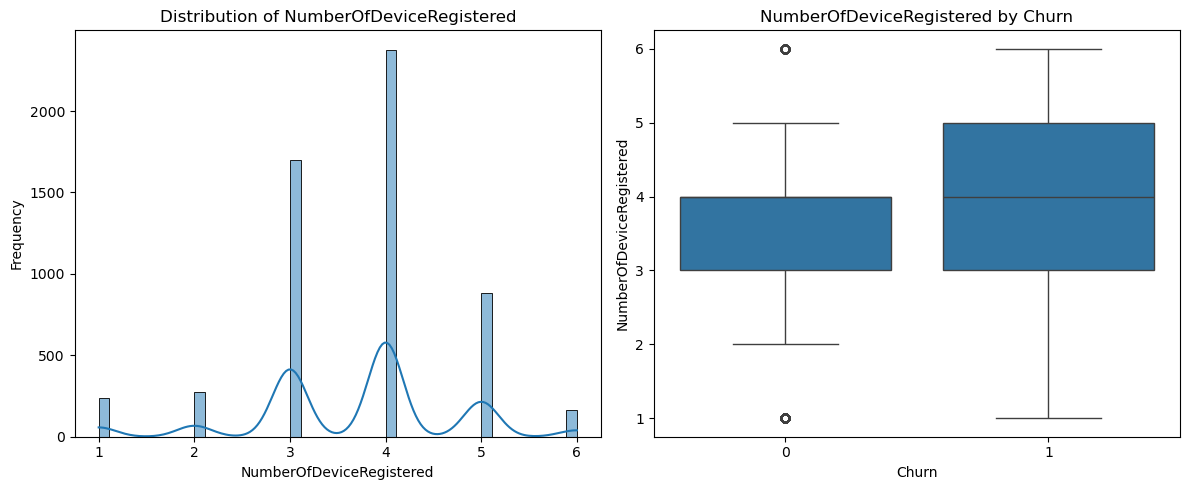

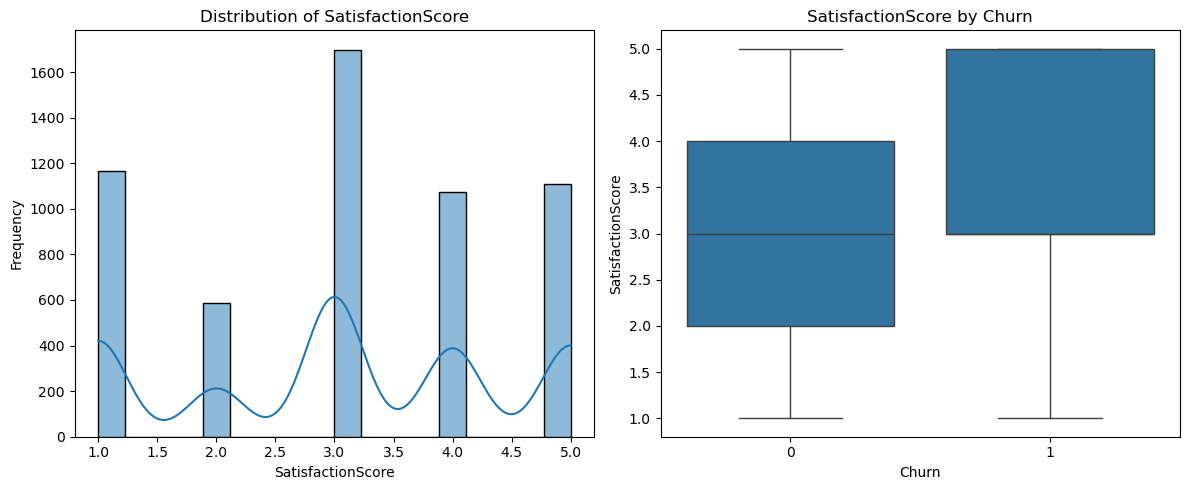

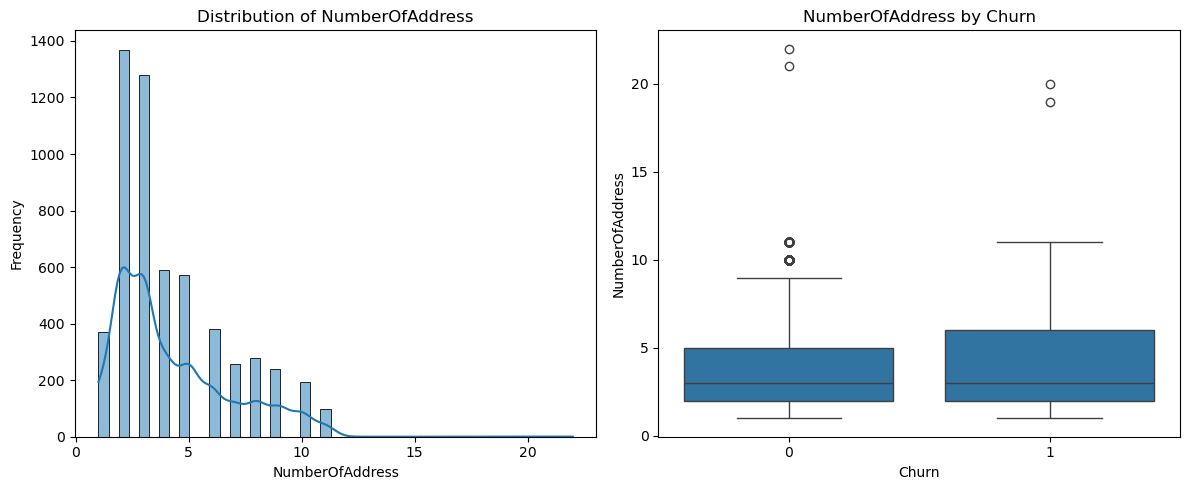

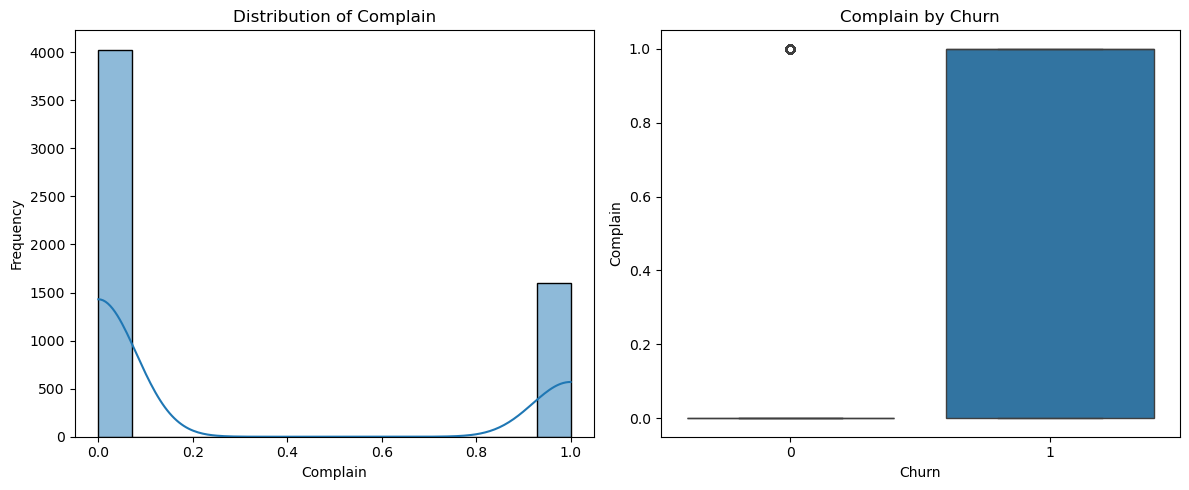

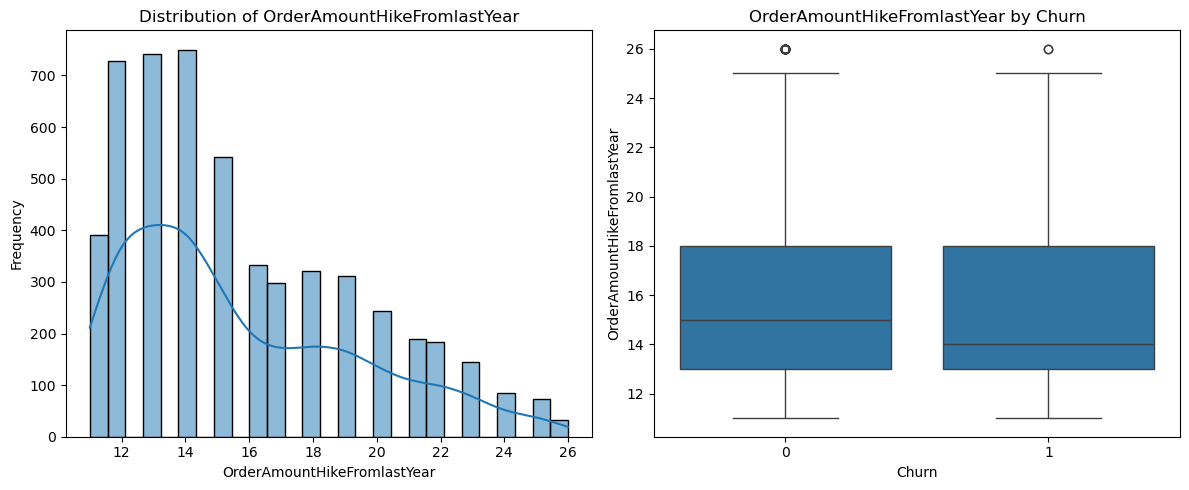

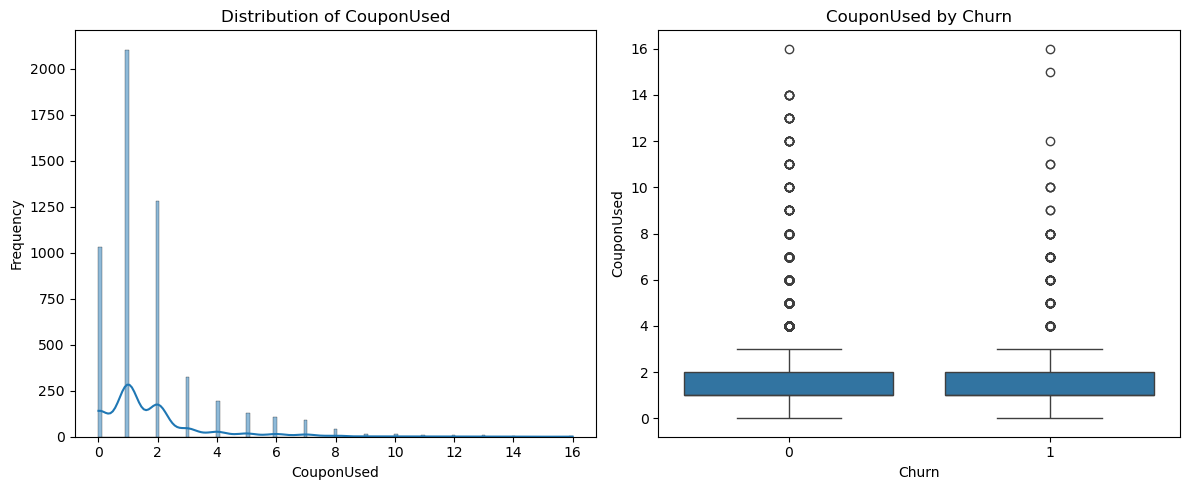

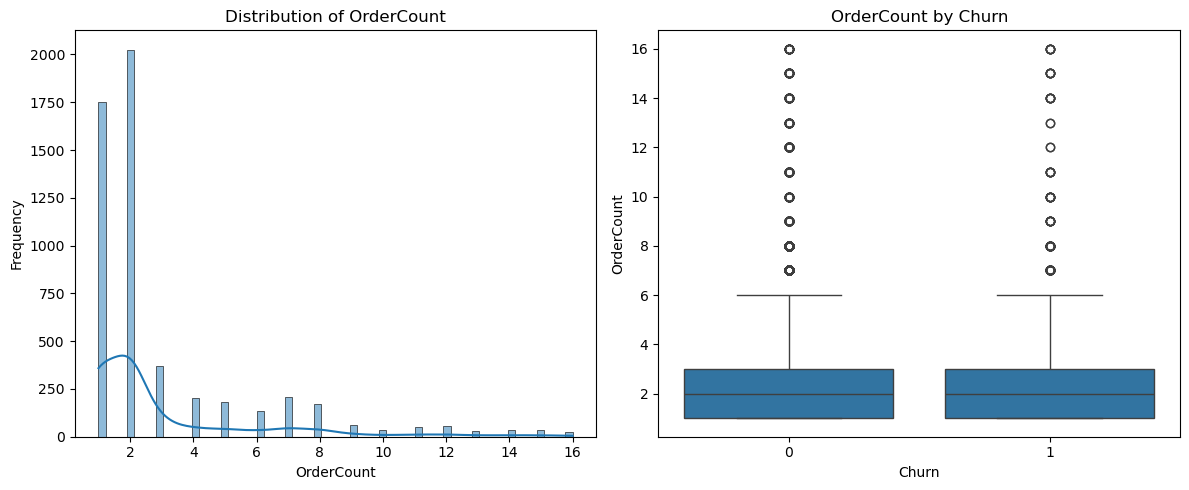

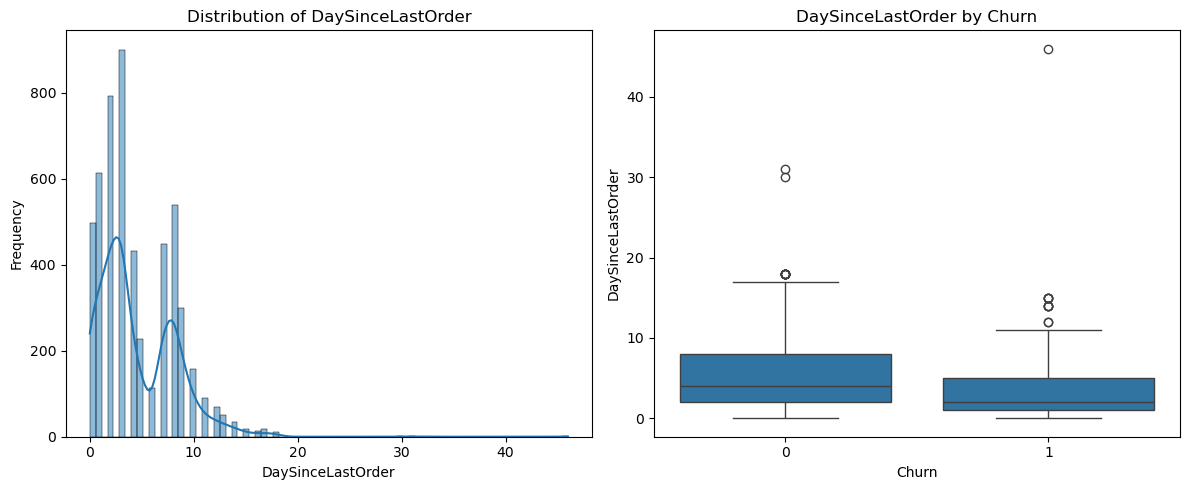

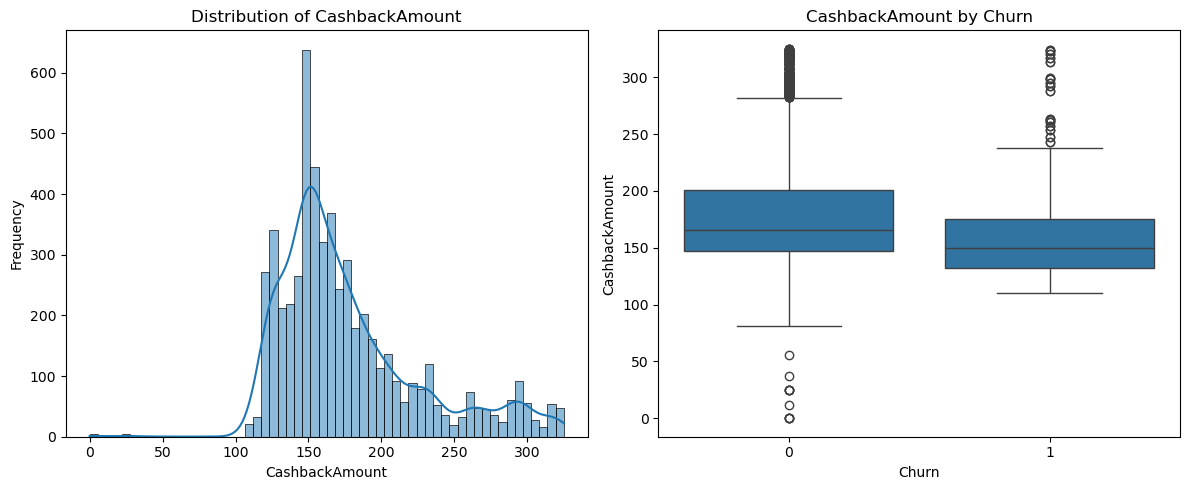

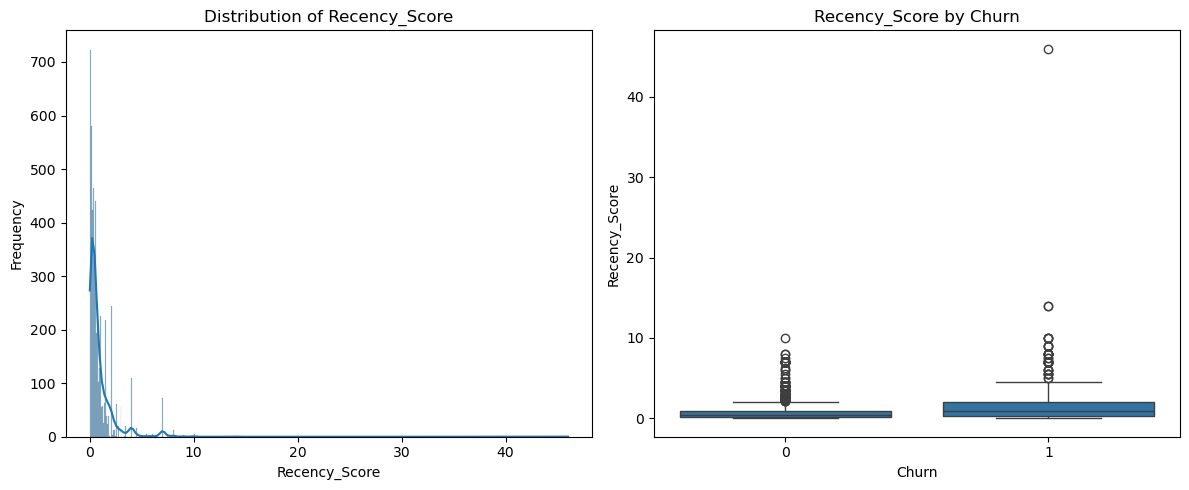

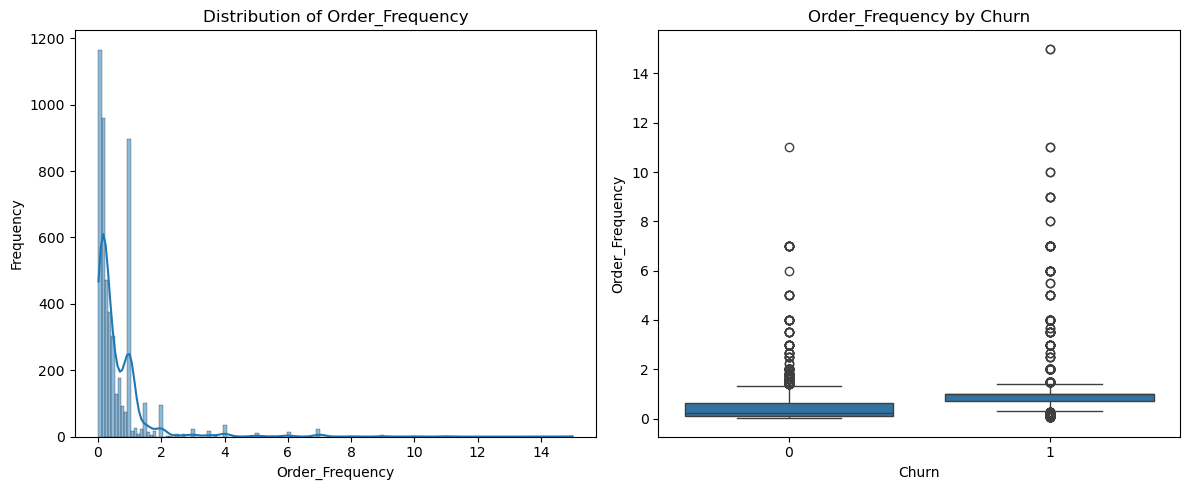

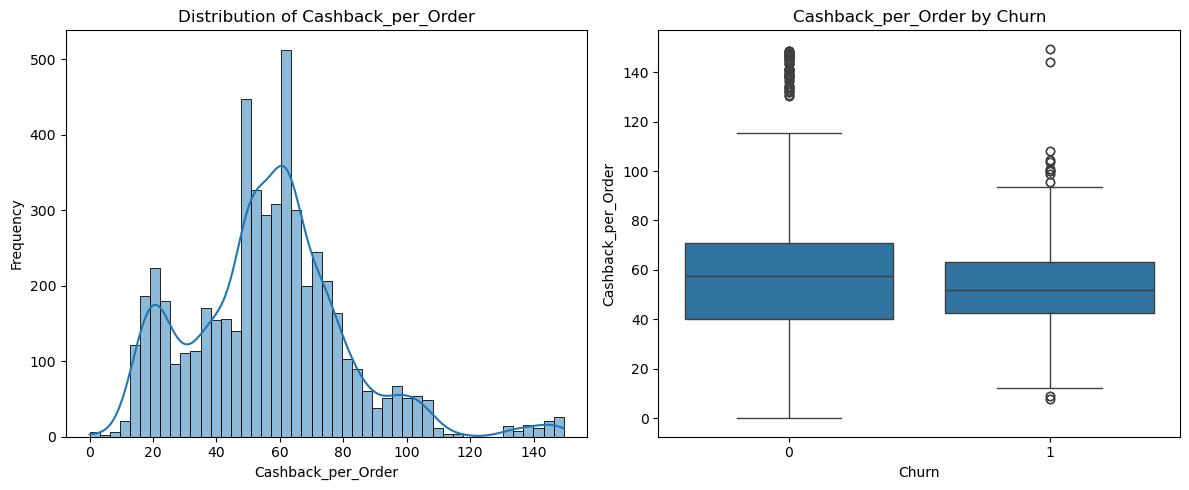

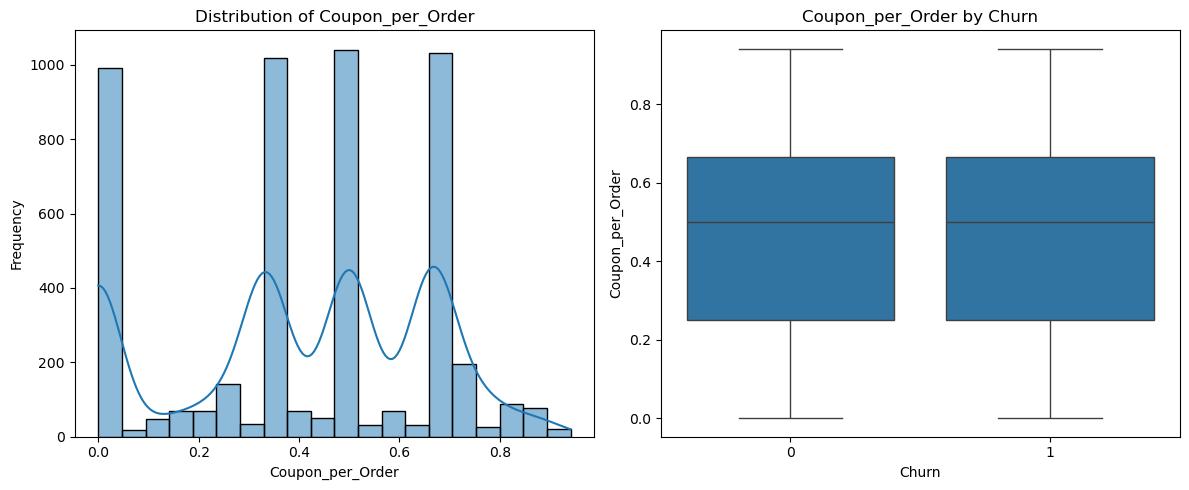

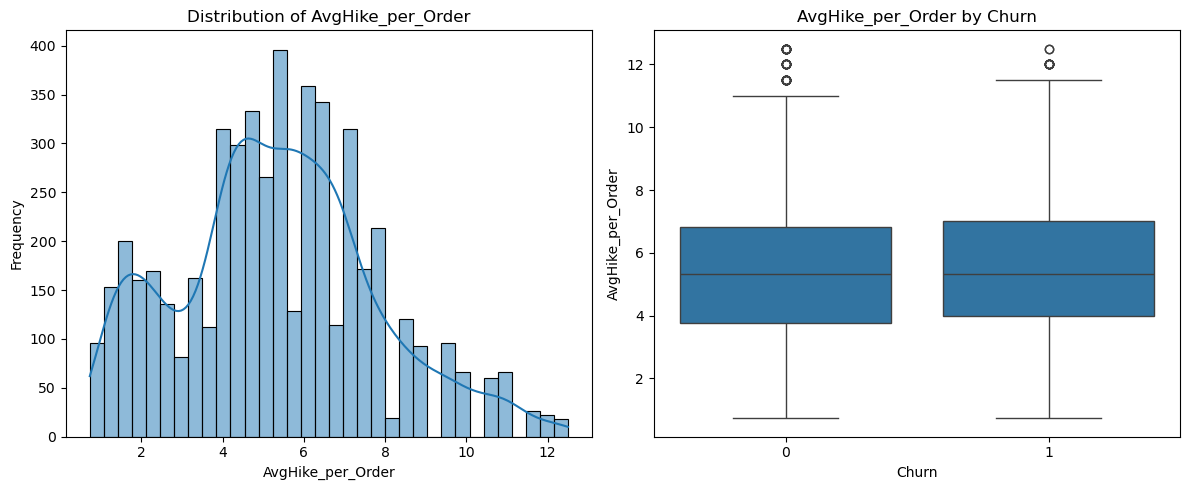

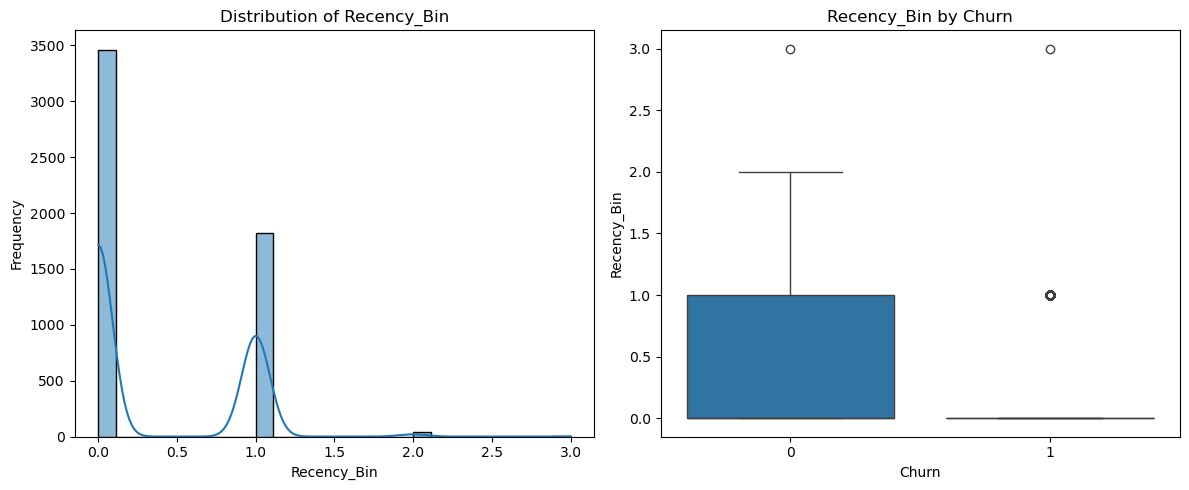

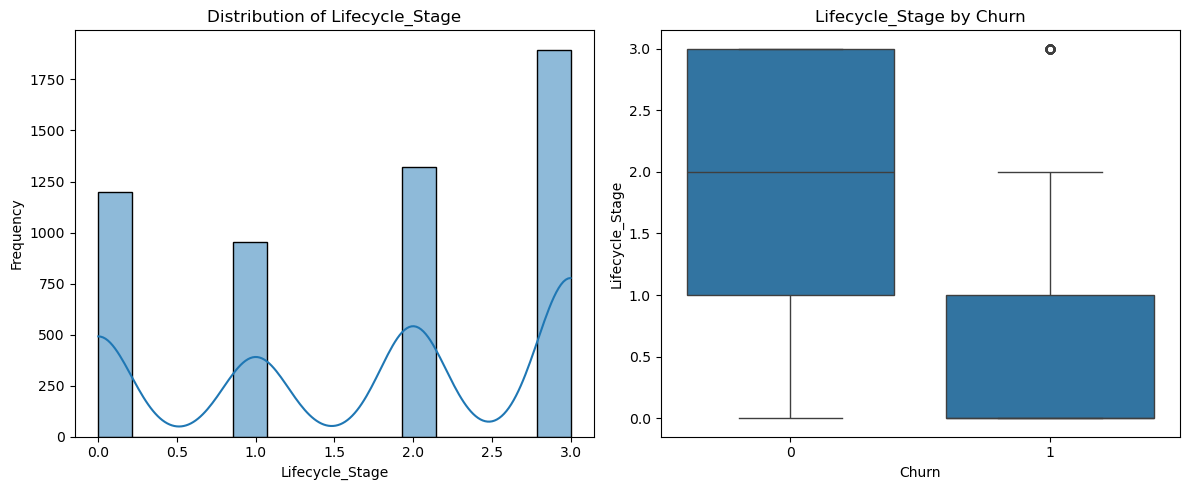

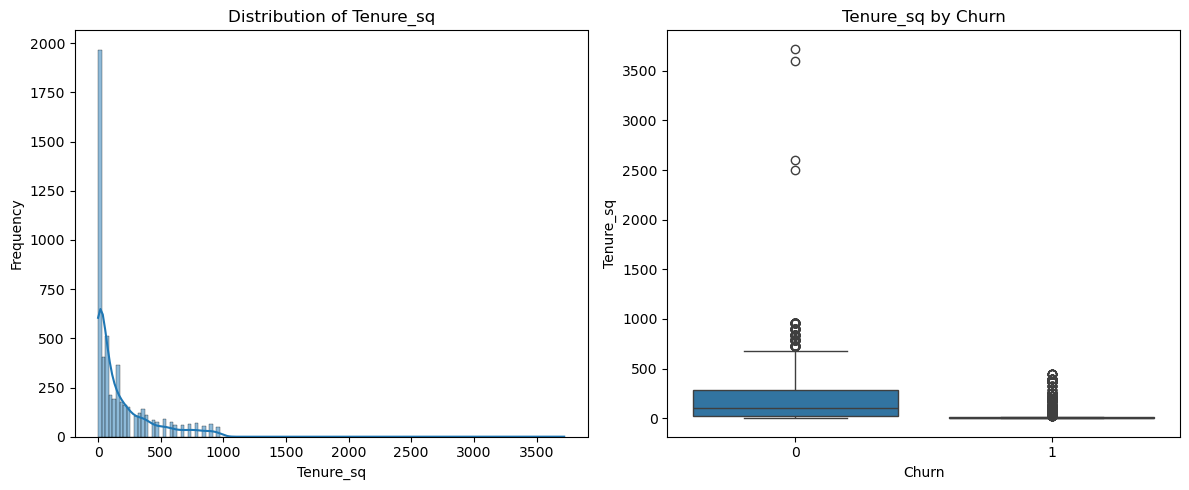

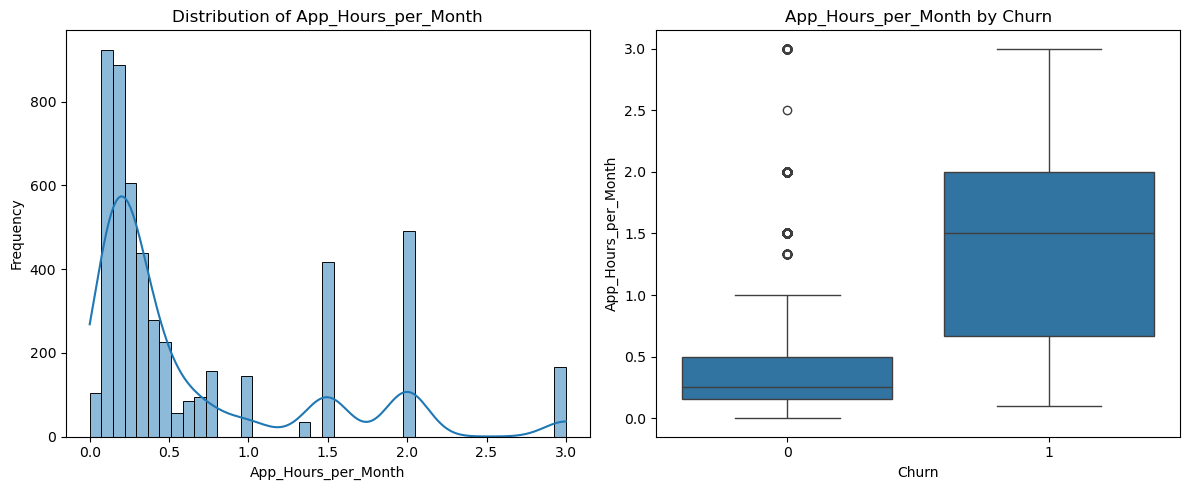

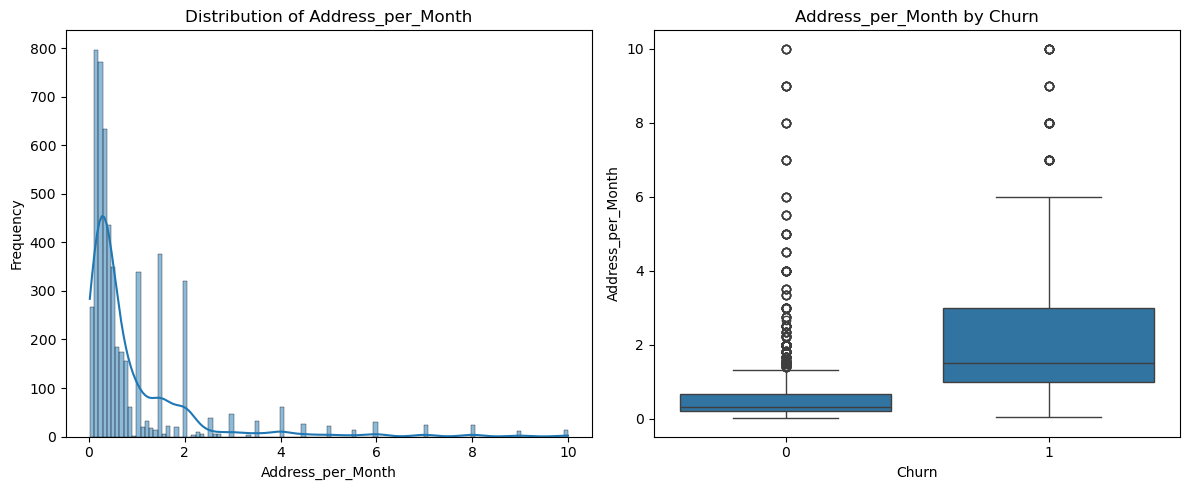

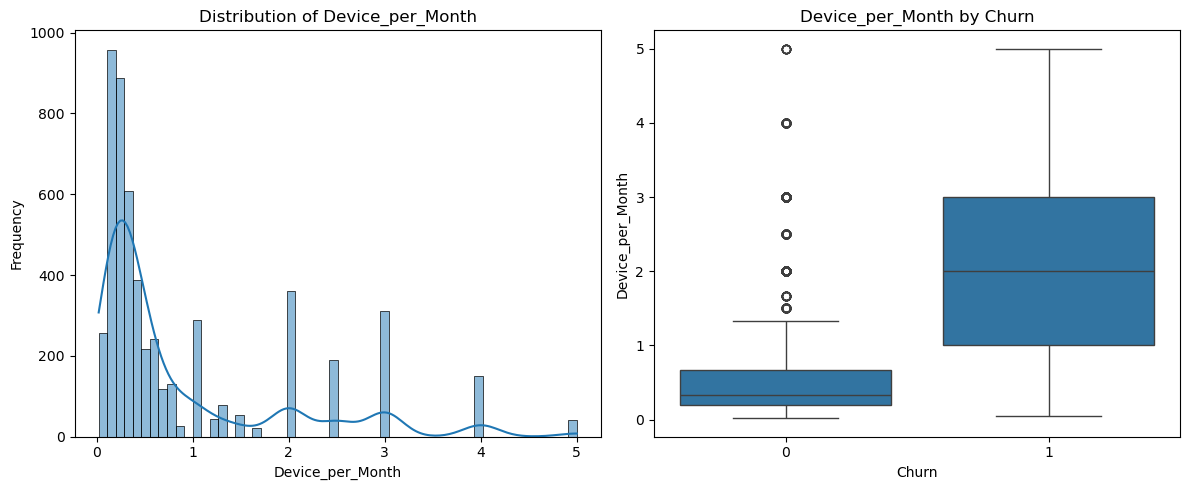

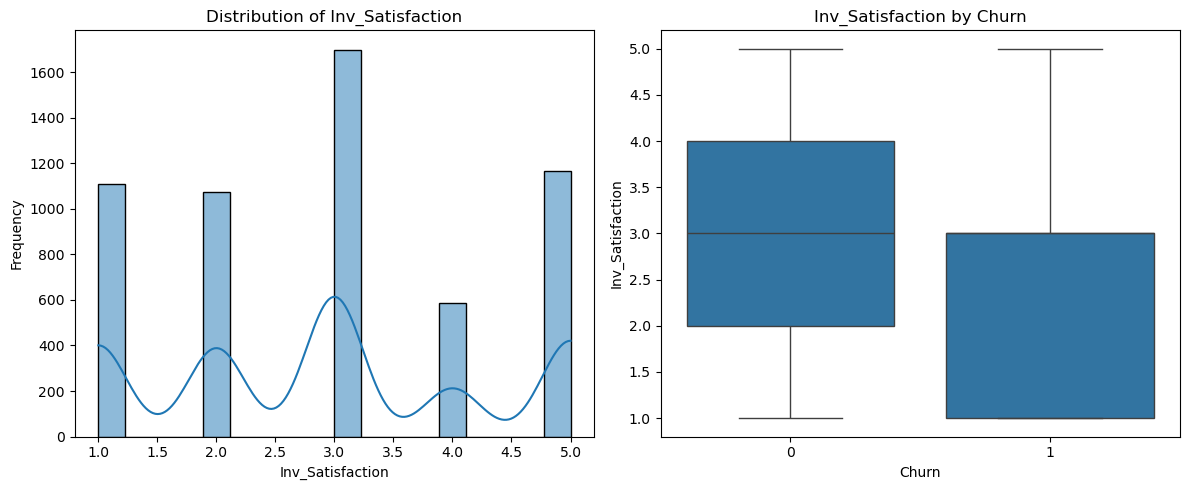

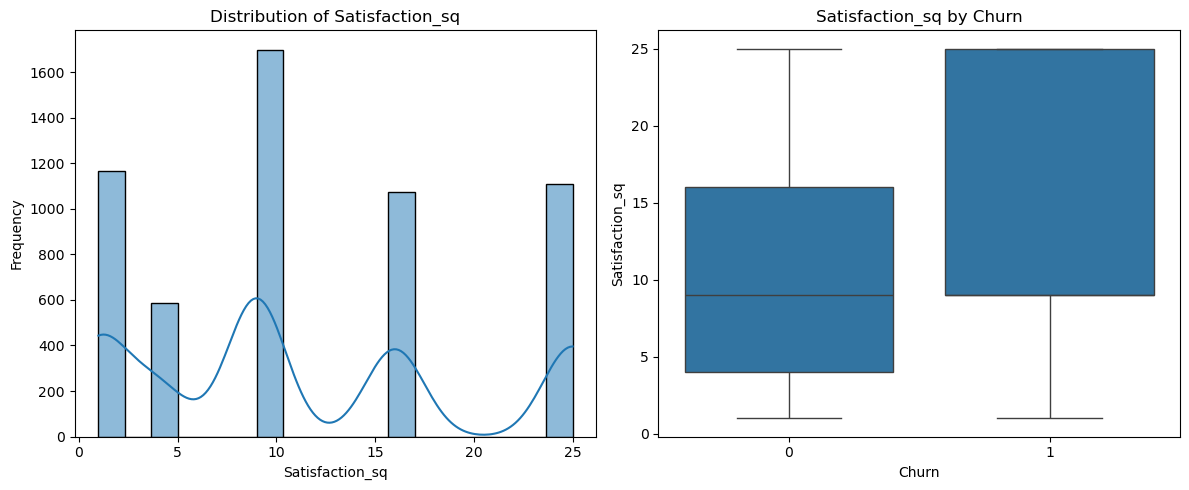

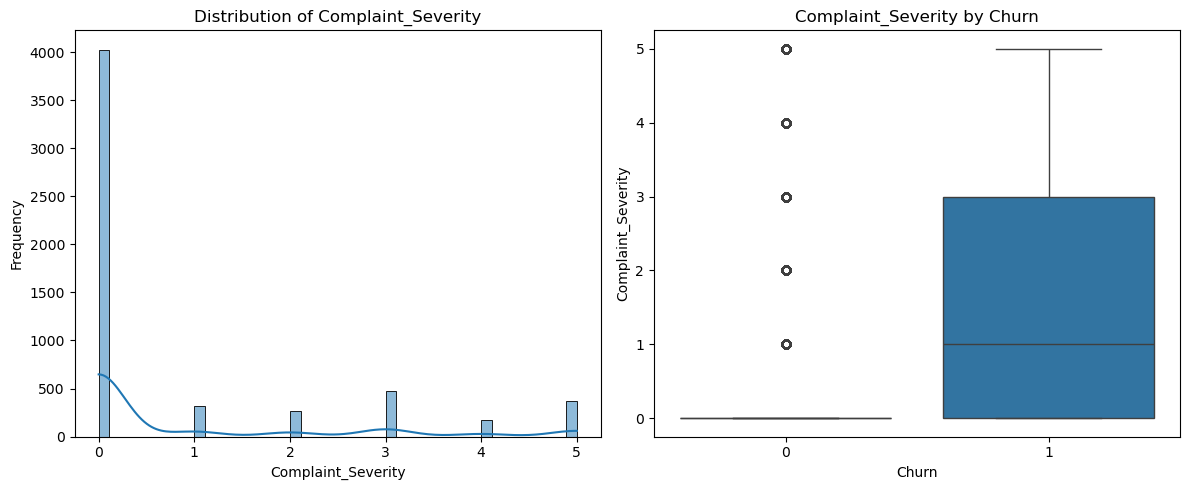

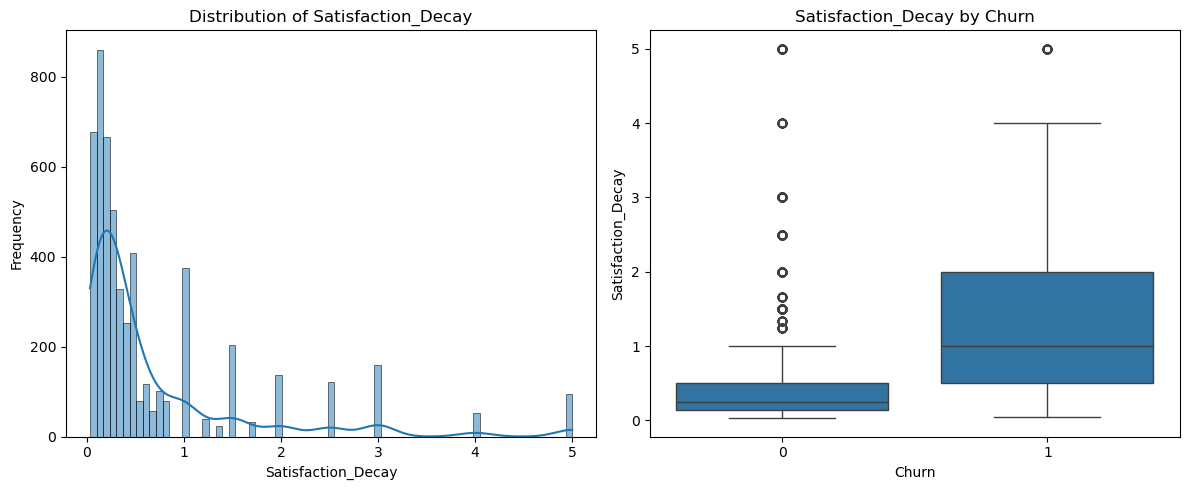

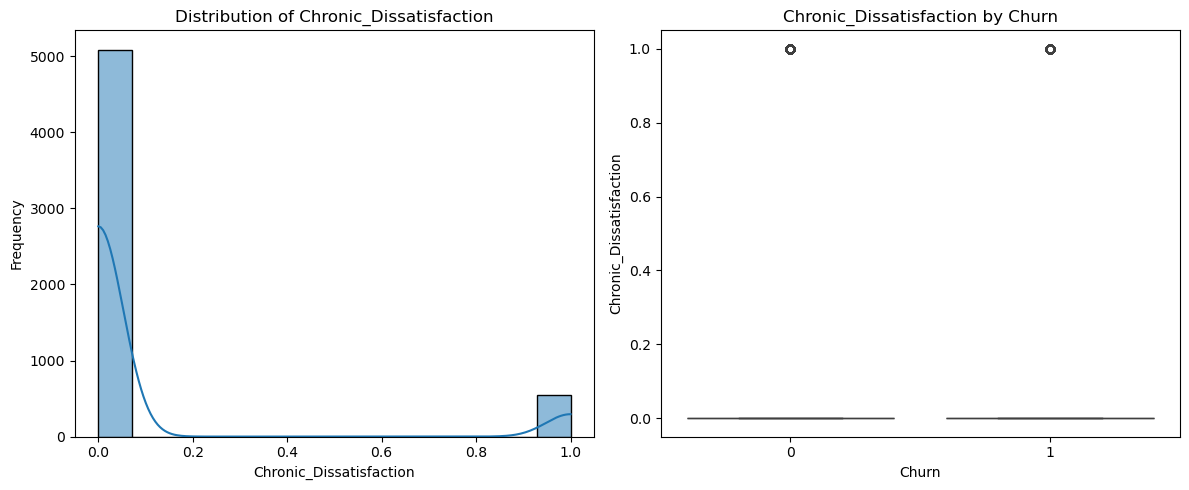

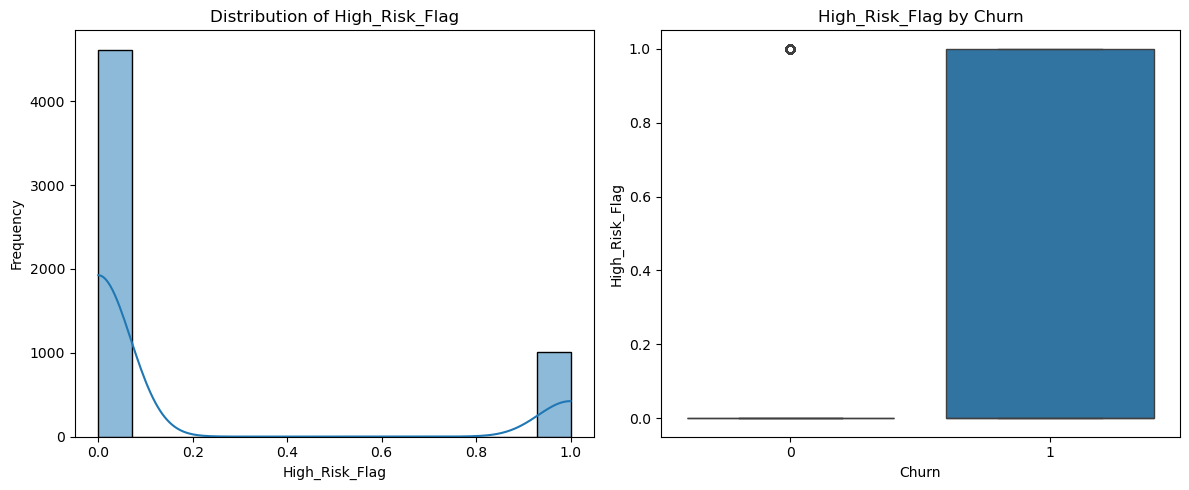

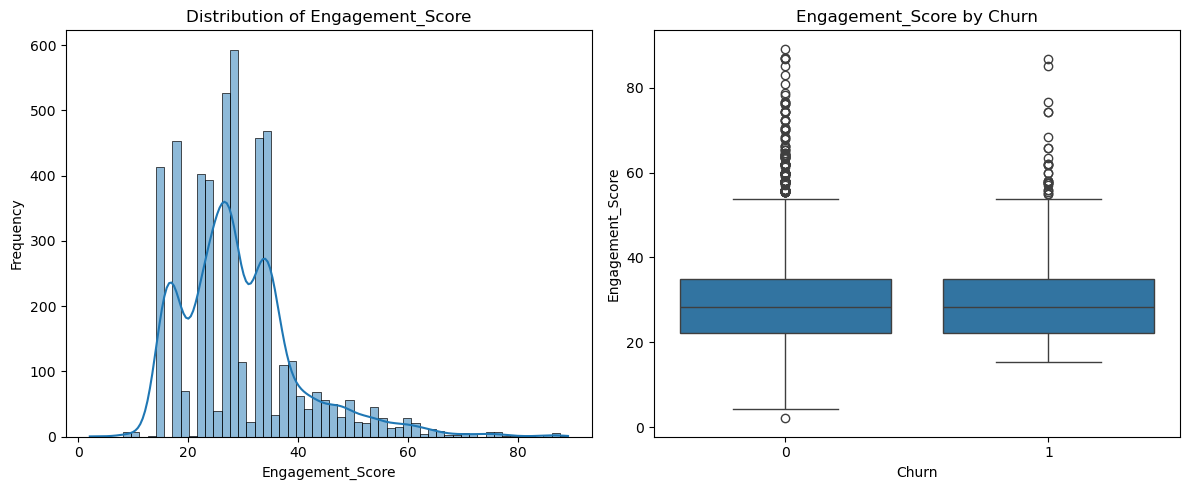

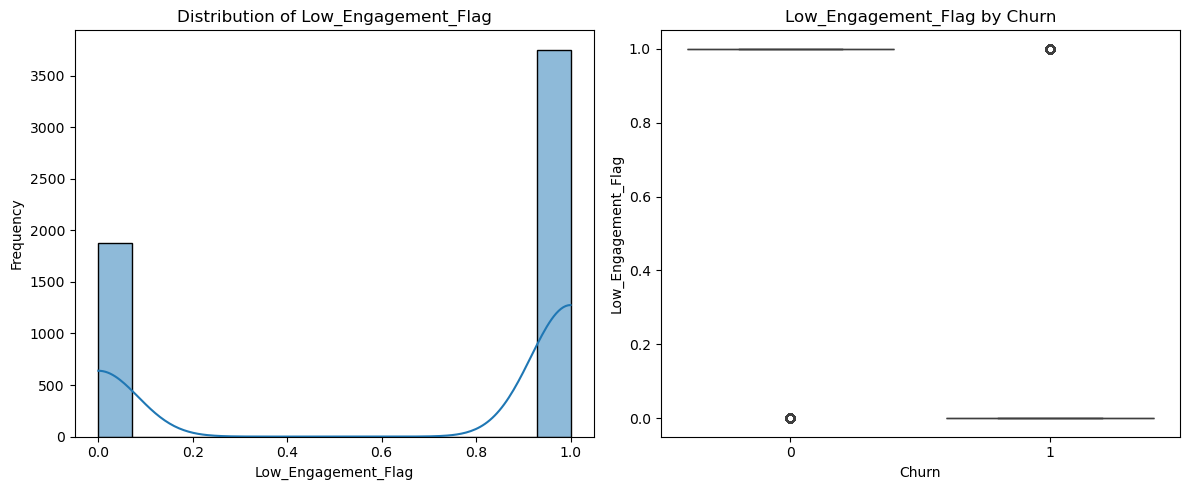

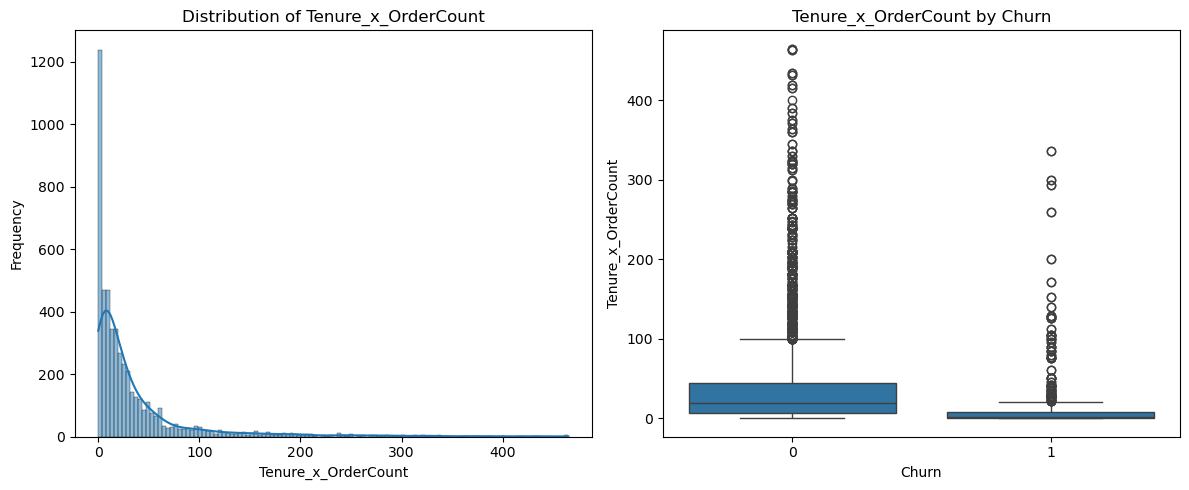

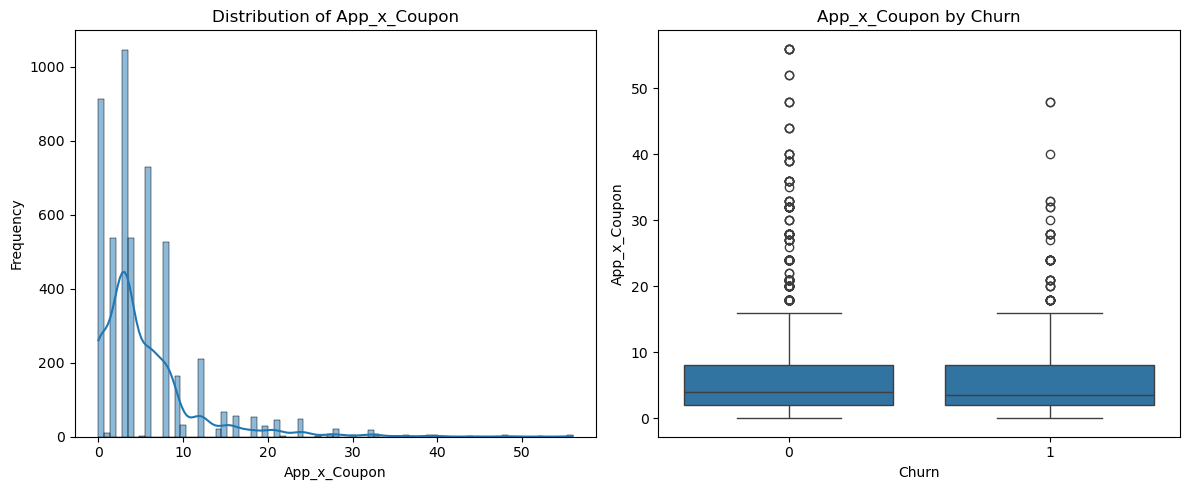

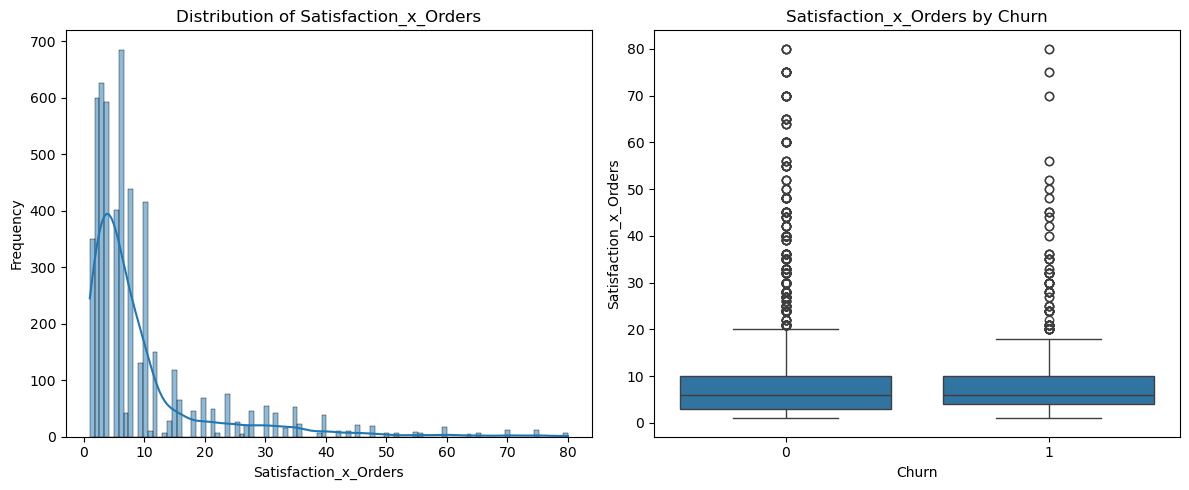

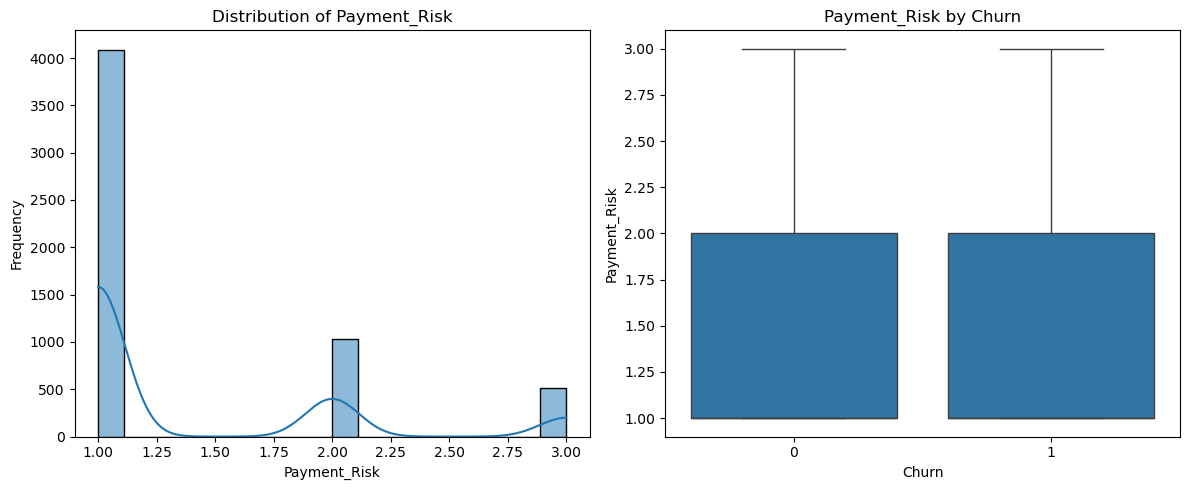

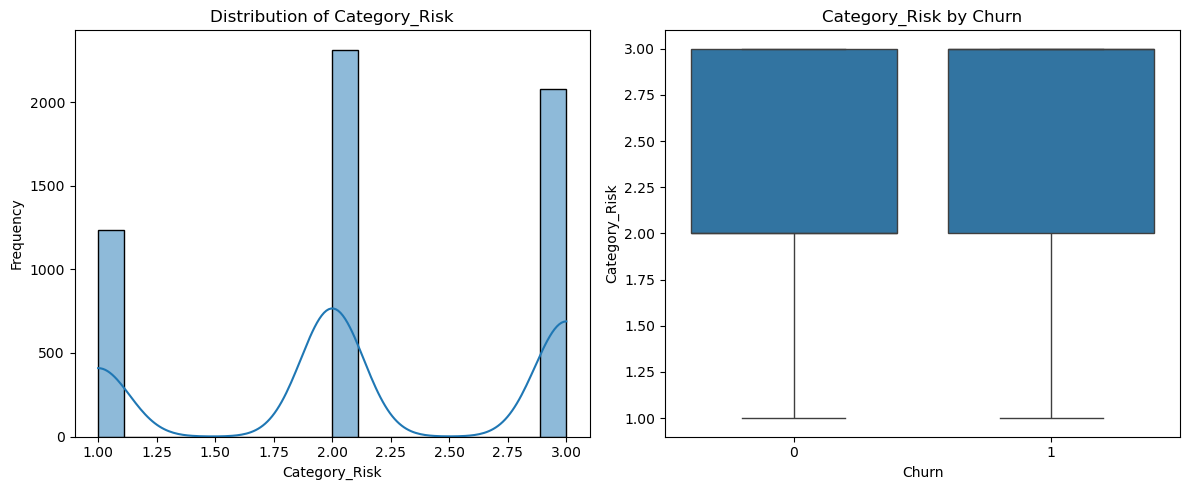

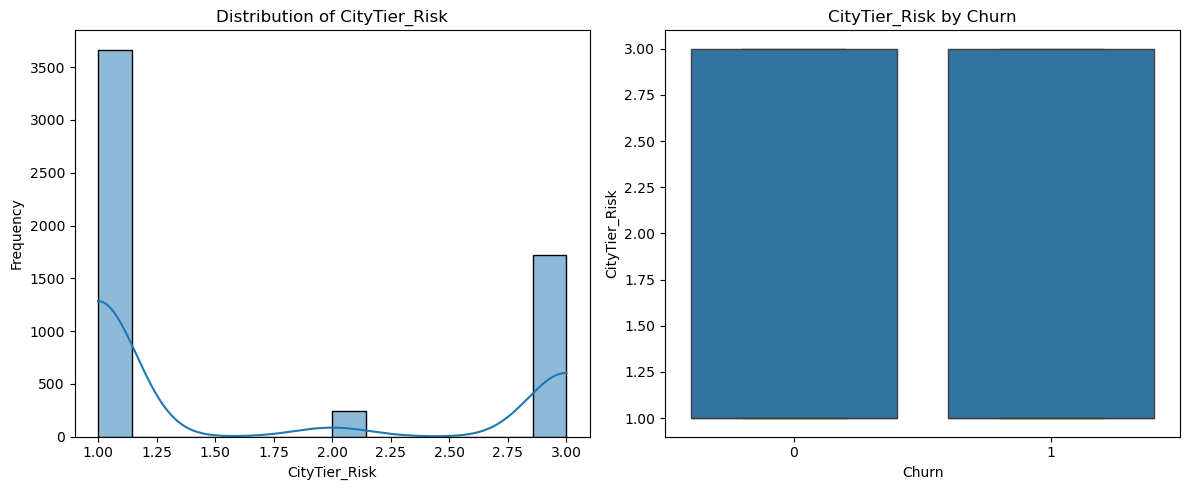

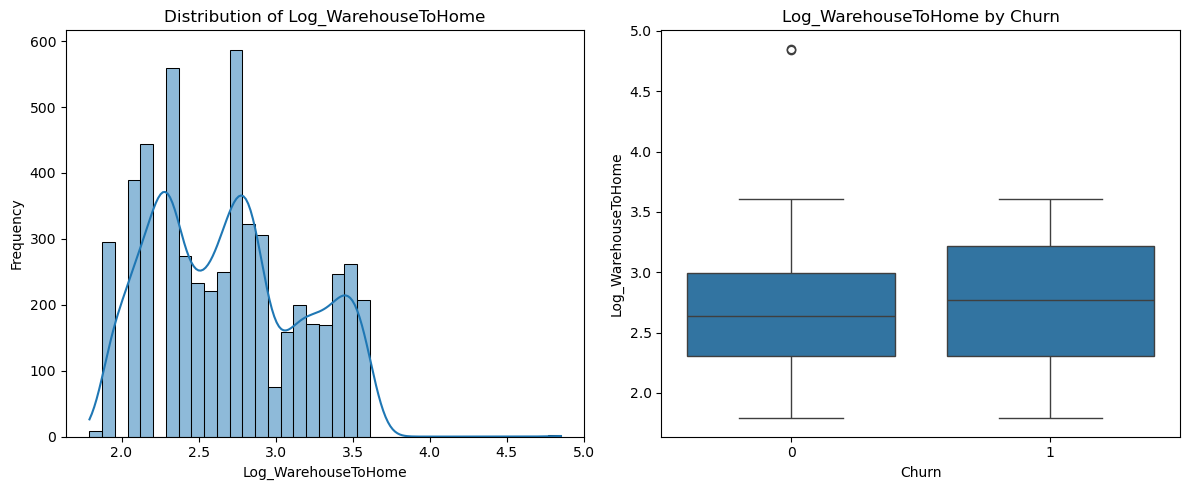

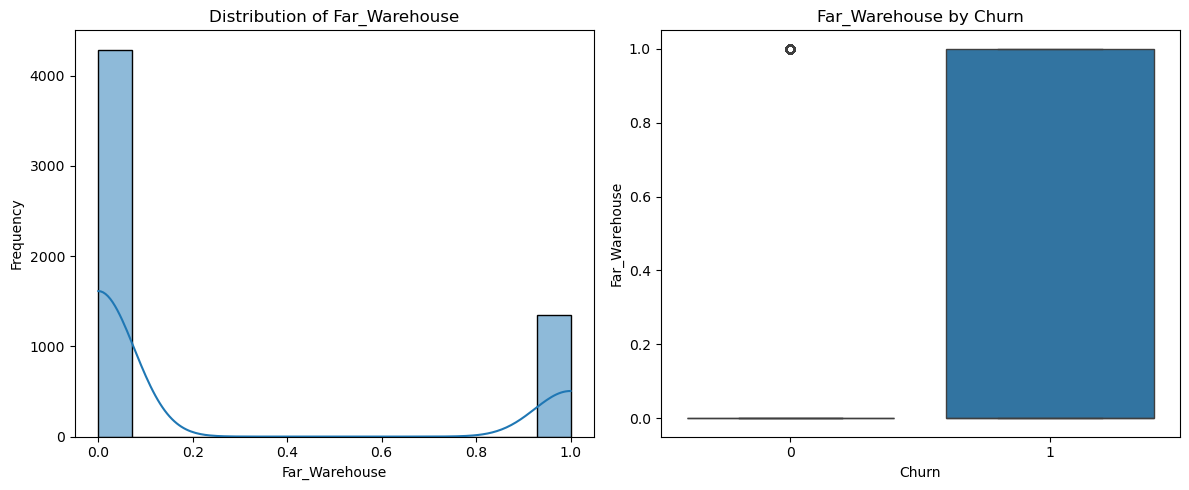

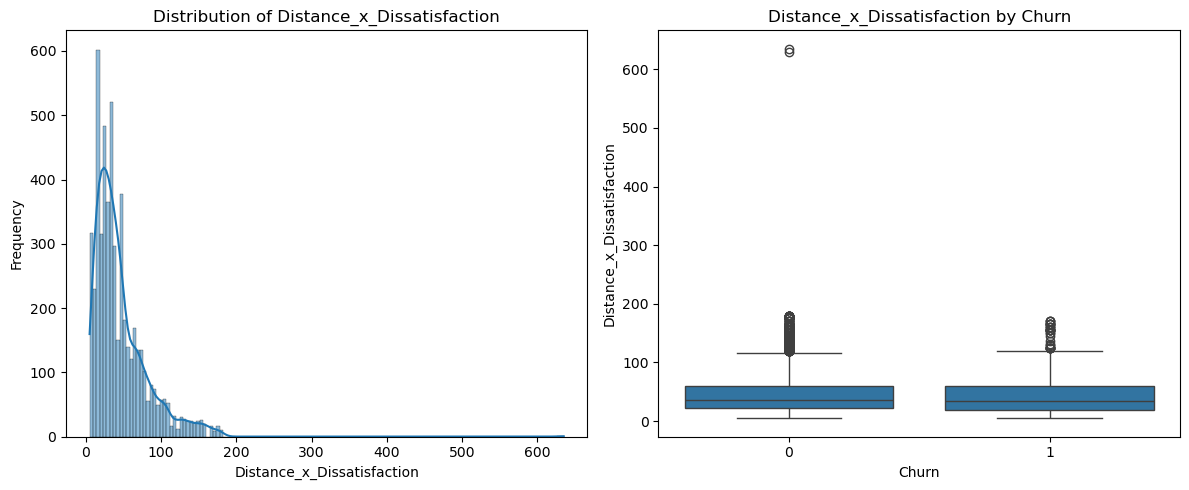

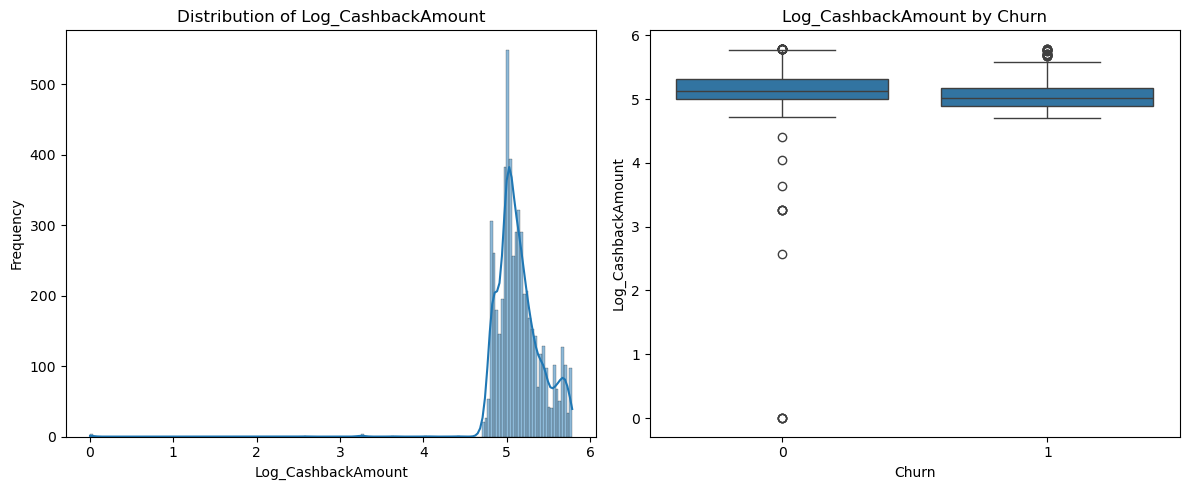

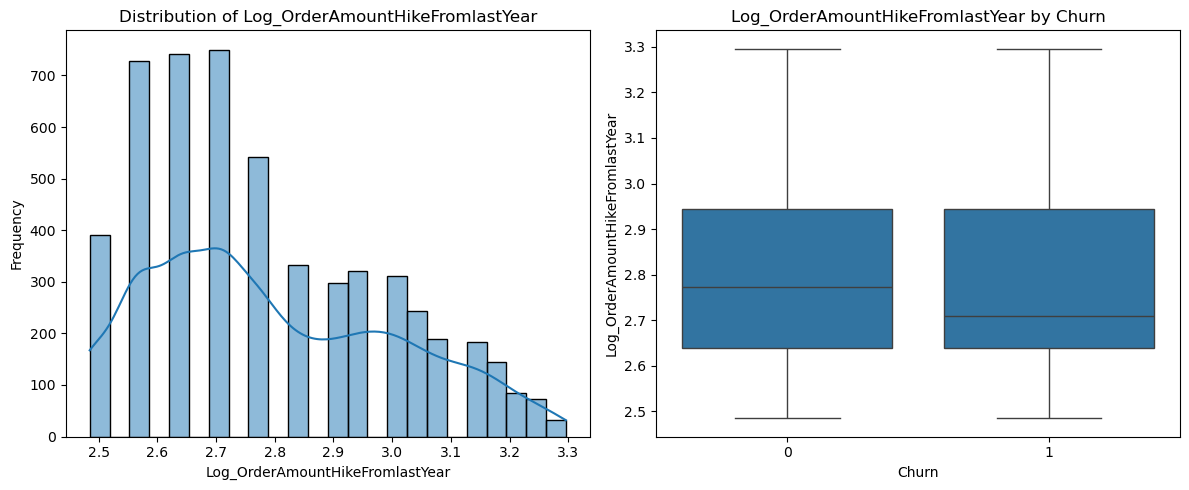

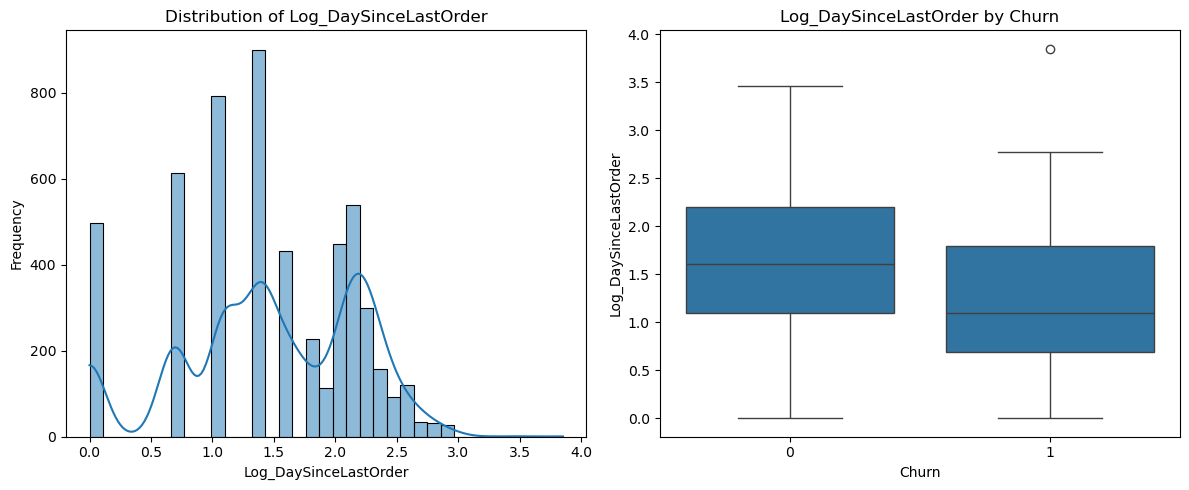

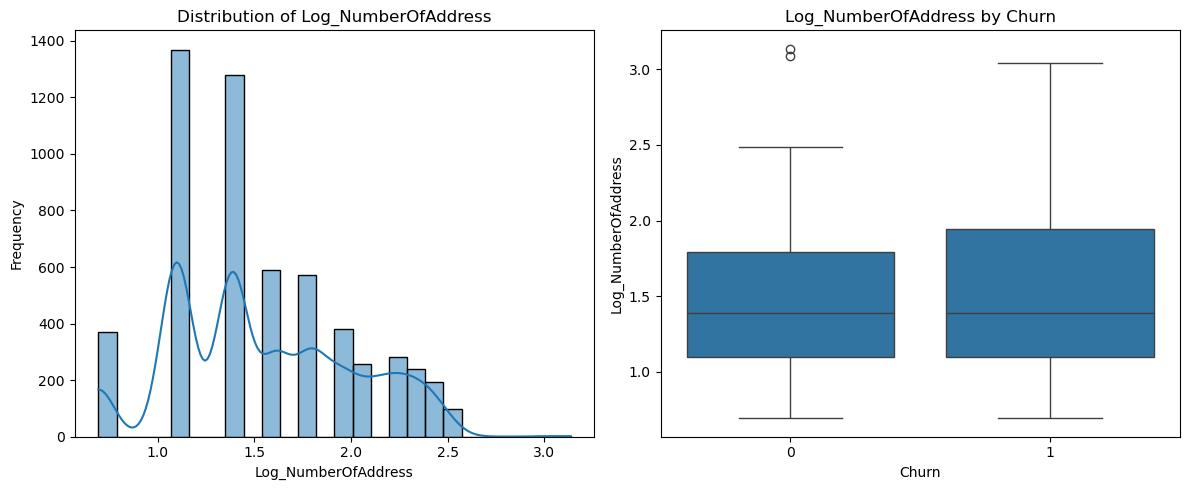

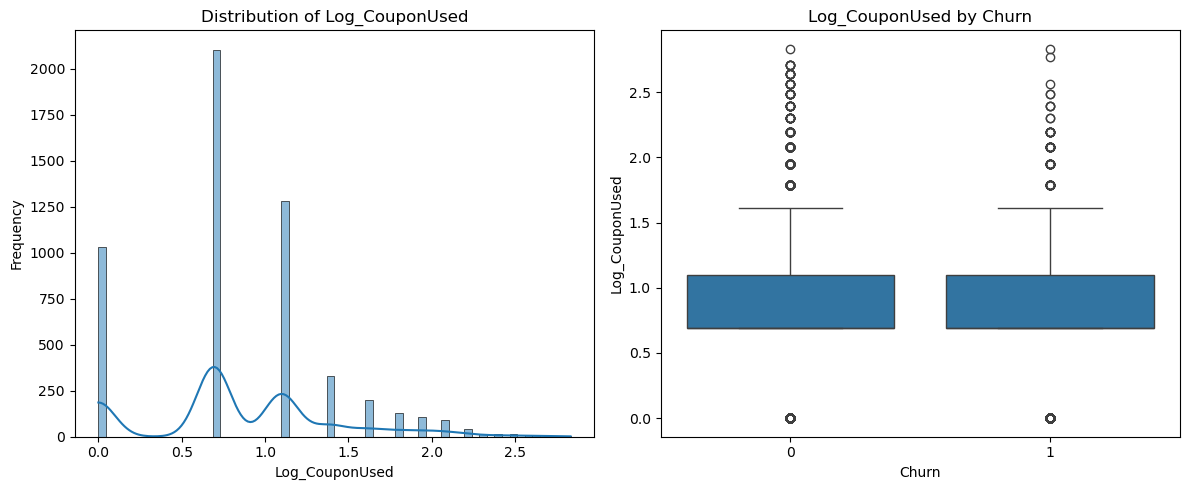

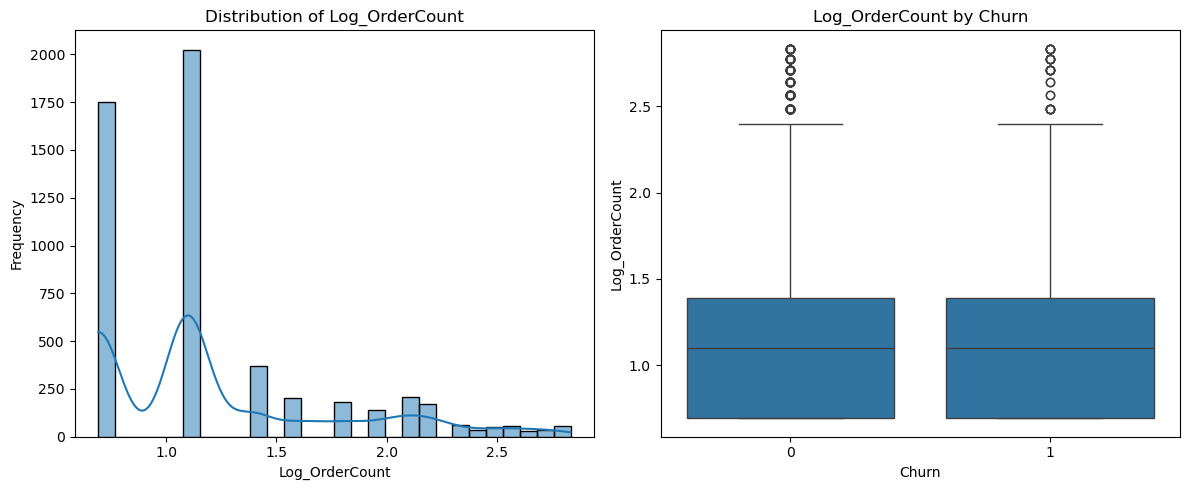

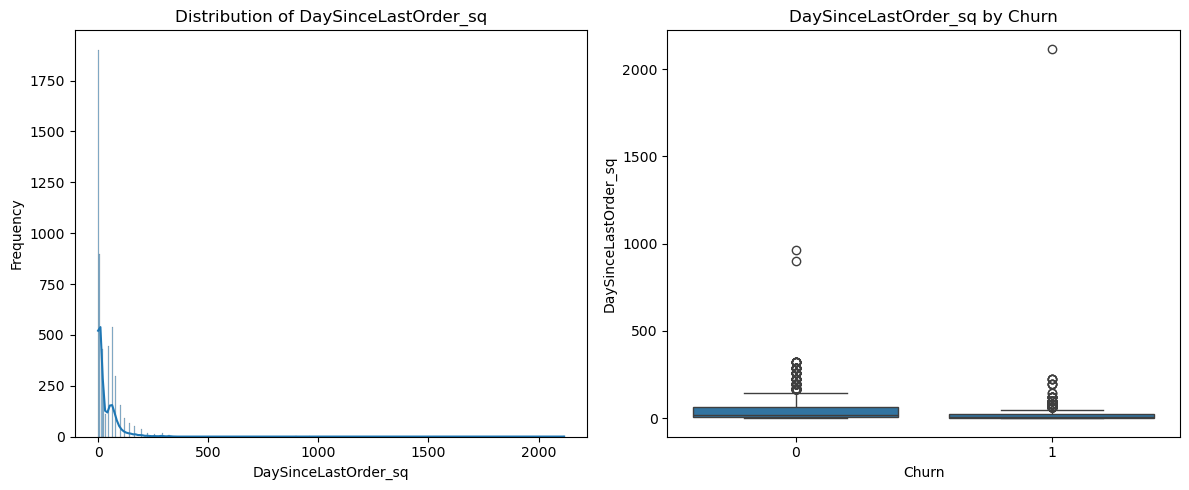

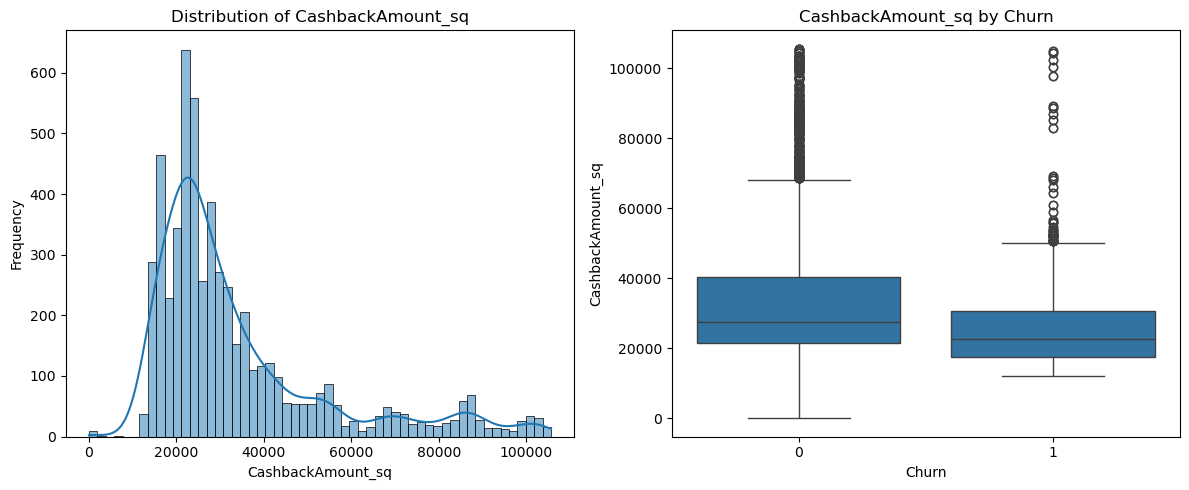

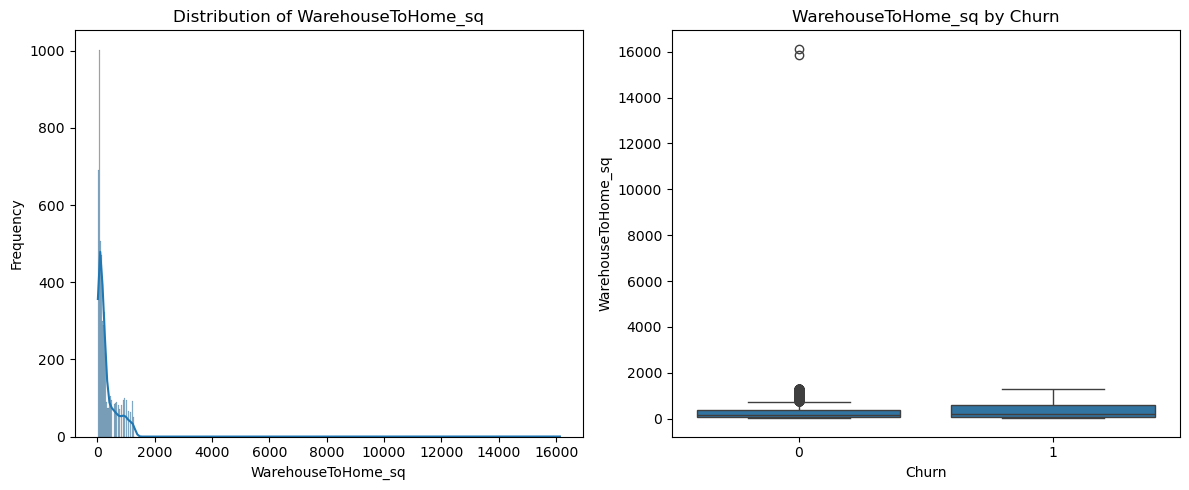

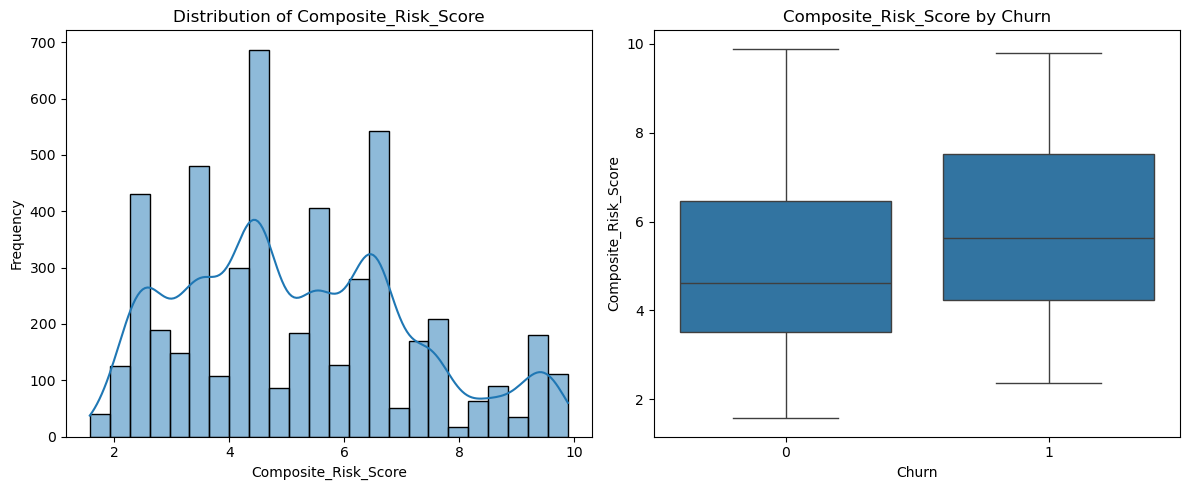

In [79]:
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram for distribution
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Box plot for relationship with Churn
    sns.boxplot(x=TARGET_COL, y=col, data=df, ax=axes[1])
    axes[1].set_title(f'{col} by {TARGET_COL}')
    axes[1].set_xlabel(TARGET_COL)
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()


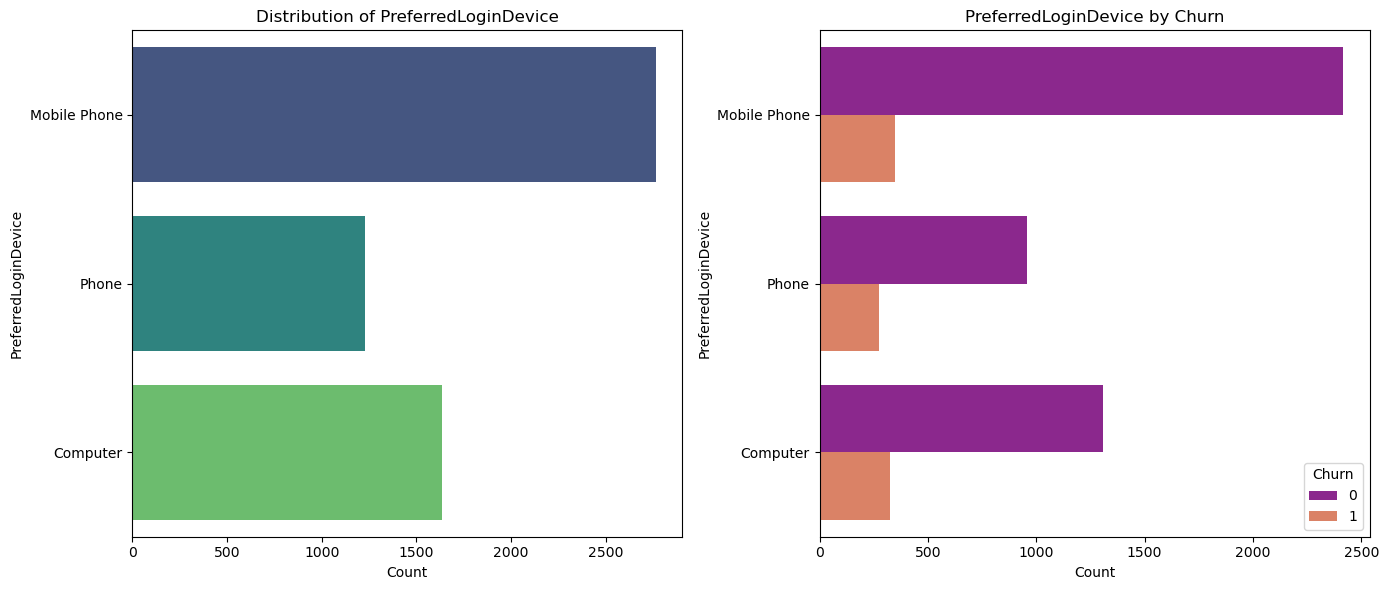

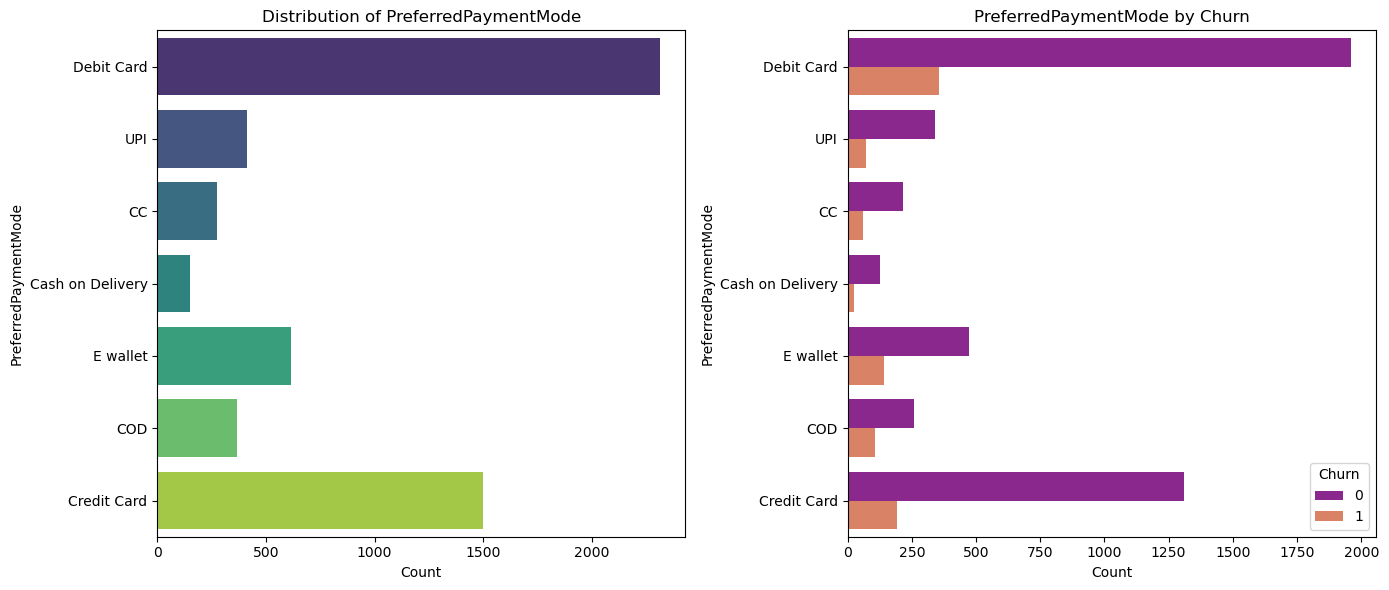

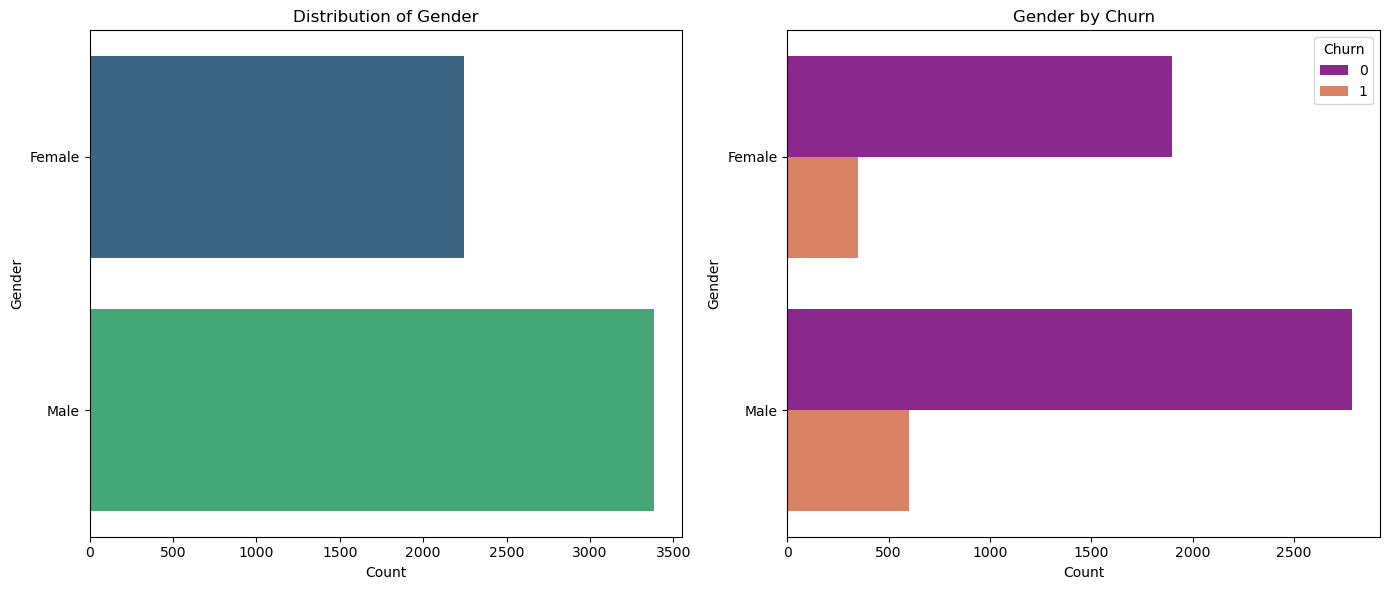

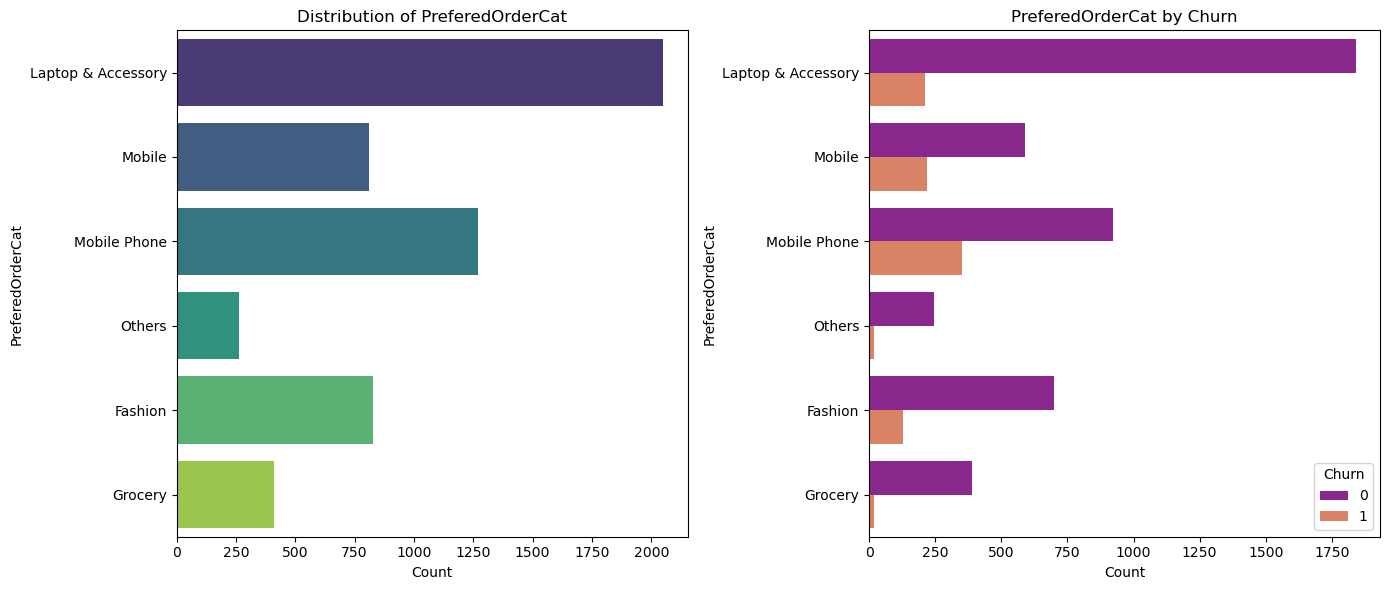

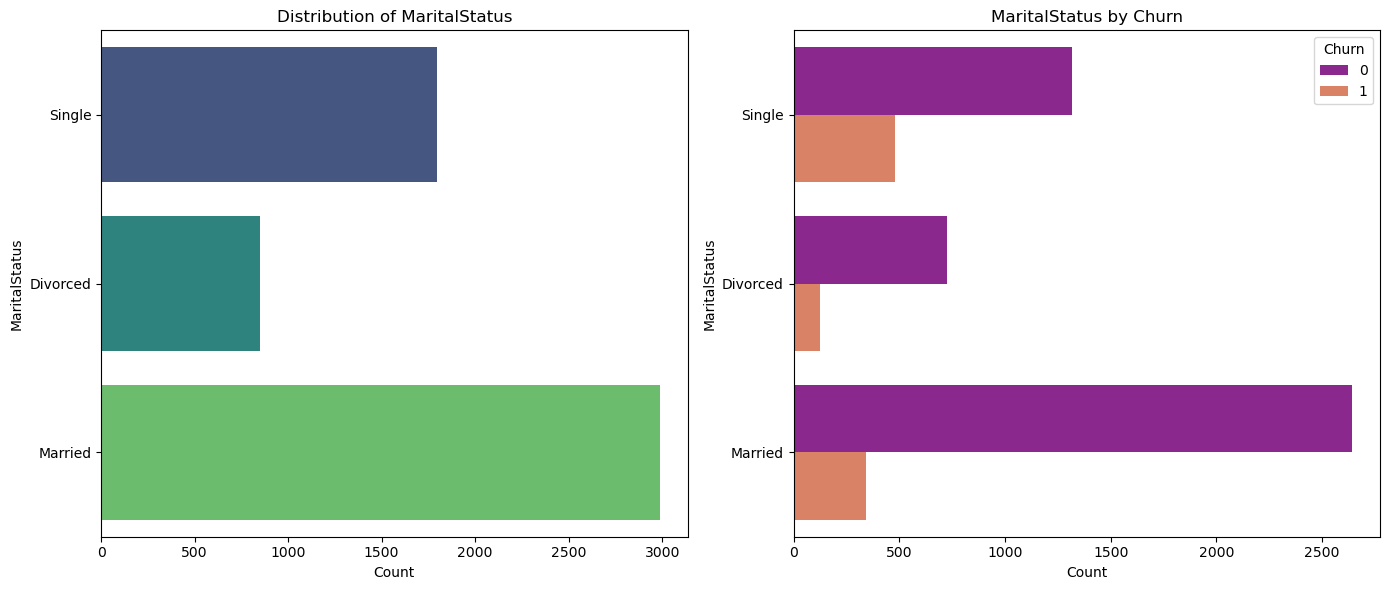

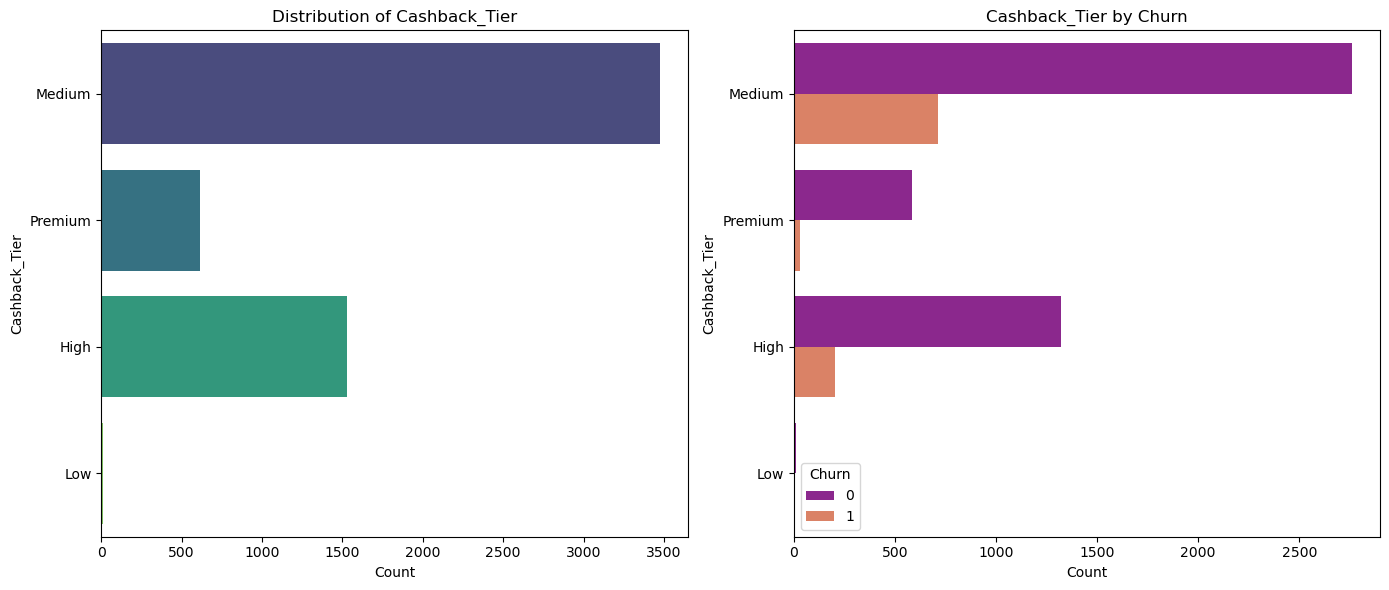

In [80]:
for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Bar plot for category distribution
    sns.countplot(y=col, data=df, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel(col)

    # Count plot for relationship with Churn
    sns.countplot(y=col, hue=TARGET_COL, data=df, ax=axes[1], palette='plasma')
    axes[1].set_title(f'{col} by {TARGET_COL}')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel(col)
    axes[1].legend(title=TARGET_COL)

    plt.tight_layout()
    plt.show()

## Handle Missing Values

### Subtask:
Address missing values in the dataset by imputing numerical columns with their median values.


In [82]:
# Report missing values (imputation will happen AFTER the train/test split to avoid data leakage)
missing_numerical_cols = [col for col in numerical_cols if df[col].isnull().any()]
missing_categorical_cols = [col for col in categorical_cols if df[col].isnull().any()]

print(f"Numerical columns with missing values: {missing_numerical_cols}")
print(f"Categorical columns with missing values: {missing_categorical_cols}")
print("\nNote: Imputation will be fit on TRAINING data only (after split) to prevent data leakage.")

Numerical columns with missing values: ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'Recency_Score', 'Order_Frequency', 'Cashback_per_Order', 'Coupon_per_Order', 'AvgHike_per_Order', 'Recency_Bin', 'Lifecycle_Stage', 'Tenure_sq', 'App_Hours_per_Month', 'Address_per_Month', 'Device_per_Month', 'Satisfaction_Decay', 'Engagement_Score', 'Tenure_x_OrderCount', 'App_x_Coupon', 'Satisfaction_x_Orders', 'Log_WarehouseToHome', 'Distance_x_Dissatisfaction', 'Log_OrderAmountHikeFromlastYear', 'Log_DaySinceLastOrder', 'Log_CouponUsed', 'Log_OrderCount', 'DaySinceLastOrder_sq', 'WarehouseToHome_sq', 'Composite_Risk_Score']
Categorical columns with missing values: []

Note: Imputation will be fit on TRAINING data only (after split) to prevent data leakage.


In [83]:
# Imputation will happen after the train/test split (see below).
# This cell is kept as a placeholder for flow continuity.
print("Imputation deferred until after train/test split to avoid data leakage.")

Imputation deferred until after train/test split to avoid data leakage.


## Process Categorical Features

### Subtask:
Identify and encode categorical features using appropriate methods like OneHotEncoder, preparing them for machine learning models.


In [84]:
# Categorical imputation will also happen after the train/test split.
print("Categorical imputation deferred until after train/test split to avoid data leakage.")

Categorical imputation deferred until after train/test split to avoid data leakage.


In [85]:
# OneHotEncoding will happen after the train/test split (fit on train, transform both).
print("OneHotEncoding deferred until after train/test split to avoid data leakage.")

OneHotEncoding deferred until after train/test split to avoid data leakage.


## Scale Numerical Features

Scale the numerical features in the `df` dataset using `StandardScaler` to normalize their ranges.

In [86]:
# Scaling will happen after the train/test split (fit on train, transform both).
print("Scaling deferred until after train/test split to avoid data leakage.")

Scaling deferred until after train/test split to avoid data leakage.


In [87]:
# Scaling placeholder — actual scaling is done in the combined cell below.
print("Scaling deferred — see combined preprocessing cell after split.")

Scaling deferred — see combined preprocessing cell after split.


## Split Data into Training and Testing Sets

Split the preprocessed `df` dataset into training and testing sets using `train_test_split` from `sklearn.model_selection`. Ensure that the target variable 'Churn' is used for stratification to maintain the proportion of churned and non-churned customers in both sets.

In [88]:
TARGET_COL = 'Churn'
CUSTOMER_ID_COL = 'CustomerID'

X = df.drop(columns=[TARGET_COL, CUSTOMER_ID_COL])
y = df[TARGET_COL]

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"Numerical cols: {len(numerical_cols)}")
print(f"Categorical cols: {len(categorical_cols)}")

Shape of features (X): (5630, 57)
Shape of target (y): (5630,)
Numerical cols: 51
Categorical cols: 6


In [89]:
# ═══════════════════════════════════════════════════════════════════════════
# LEAKAGE-FREE PREPROCESSING: Split → Impute → OHE → Scale (fit on TRAIN only)
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ── 1. SPLIT FIRST ──
X_train_raw_cls, X_test_raw_cls, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train_raw_cls.shape}  |  Test: {X_test_raw_cls.shape}")

# ── 2. IMPUTE NUMERICAL (fit on train) ──
num_imputer_cls = SimpleImputer(strategy='median')
X_train_raw_cls[numerical_cols] = num_imputer_cls.fit_transform(X_train_raw_cls[numerical_cols])
X_test_raw_cls[numerical_cols]  = num_imputer_cls.transform(X_test_raw_cls[numerical_cols])

# ── 3. IMPUTE CATEGORICAL (fit on train) ──
cat_imputer_cls = SimpleImputer(strategy='most_frequent')
X_train_raw_cls[categorical_cols] = cat_imputer_cls.fit_transform(X_train_raw_cls[categorical_cols])
X_test_raw_cls[categorical_cols]  = cat_imputer_cls.transform(X_test_raw_cls[categorical_cols])

print("Missing after imputation (train):", X_train_raw_cls.isnull().sum().sum())
print("Missing after imputation (test):", X_test_raw_cls.isnull().sum().sum())

# ── 4. ONE-HOT ENCODE CATEGORICAL (fit on train) ──
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_encoded = encoder.fit_transform(X_train_raw_cls[categorical_cols])
test_encoded  = encoder.transform(X_test_raw_cls[categorical_cols])

ohe_cols = encoder.get_feature_names_out(categorical_cols)

X_train_cls = X_train_raw_cls.drop(columns=categorical_cols).copy()
X_test_cls  = X_test_raw_cls.drop(columns=categorical_cols).copy()

X_train_cls = pd.concat([
    X_train_cls.reset_index(drop=True),
    pd.DataFrame(train_encoded, columns=ohe_cols)
], axis=1)

X_test_cls = pd.concat([
    X_test_cls.reset_index(drop=True),
    pd.DataFrame(test_encoded, columns=ohe_cols)
], axis=1)

# ── 5. SCALE NUMERICAL (fit on train) ──
numerical_cols_to_scale = [c for c in X_train_cls.columns
                           if c in numerical_cols or c.startswith('Log_')
                           or c.endswith('_sq') or c.endswith('_Score')
                           or c in X_train_raw_cls.select_dtypes(include=np.number).columns.tolist()]
# Simpler: scale ALL numerical columns in the final dataframe
numerical_cols_to_scale = X_train_cls.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X_train_cls[numerical_cols_to_scale] = scaler.fit_transform(X_train_cls[numerical_cols_to_scale])
X_test_cls[numerical_cols_to_scale]  = scaler.transform(X_test_cls[numerical_cols_to_scale])

# ── Final assignment ──
X_train = X_train_cls
X_test  = X_test_cls

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n--- Target distribution in training set ---")
print(y_train.value_counts(normalize=True))

print("\n--- Target distribution in test set ---")
print(y_test.value_counts(normalize=True))

print("\ Leakage-free preprocessing complete. Encoder/scaler fit on TRAINING data only.")

Train: (4504, 57)  |  Test: (1126, 57)
Missing after imputation (train): 0
Missing after imputation (test): 0

X_train shape: (4504, 76)
X_test shape: (1126, 76)
y_train shape: (4504,)
y_test shape: (1126,)

--- Target distribution in training set ---
Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64

--- Target distribution in test set ---
Churn
0    0.831261
1    0.168739
Name: proportion, dtype: float64
\ Leakage-free preprocessing complete. Encoder/scaler fit on TRAINING data only.


This step is to ensure that the dataset is fully preprocessed and ready for training Gradient Boosting, Logistic Regression, and XGBoost models, summarizing the steps taken.


# Task
Train a Logistic Regression model on the preprocessed training data (`X_train`, `y_train`), and evaluate its performance on the test set (`X_test`, `y_test`) using ROC AUC, Average Precision Score, classification report, and confusion matrix.

## Train and Evaluate Logistic Regression Model

Train a Logistic Regression model on the preprocessed training data (`X_train`, `y_train`) and evaluate its performance on the test set (`X_test`, `y_test`) using ROC AUC, Average Precision Score, and display a classification report and confusion matrix. This will serve as a baseline for comparison.


In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Calculate the predicted probabilities for the positive class to compute ROC AUC and Average Precision Score, and predict the class labels to generate the classification report and confusion matrix.

## Train and Evaluate Random Forest Classifier

### Subtask:
Initialize, train, and evaluate a Random Forest Classifier on the preprocessed training data (`X_train`, `y_train`). Report its performance using ROC AUC, Average Precision Score, a classification report, and a confusion matrix on the test set (`X_test`, `y_test`).


In [91]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [92]:
y_pred_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]
y_pred_rf = rf_classifier.predict(X_test)

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
avg_precision_rf = average_precision_score(y_test, y_pred_proba_rf)
class_report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Classifier ROC AUC: {roc_auc_rf:.4f}")
print(f"Random Forest Classifier Average Precision Score: {avg_precision_rf:.4f}")
print("\nRandom Forest Classifier Classification Report:")
print(class_report_rf)
print("\nRandom Forest Classifier Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Classifier ROC AUC: 0.9985
Random Forest Classifier Average Precision Score: 0.9923

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       936
           1       0.98      0.91      0.94       190

    accuracy                           0.98      1126
   macro avg       0.98      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126


Random Forest Classifier Confusion Matrix:
[[933   3]
 [ 18 172]]


In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import numpy as np

# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Base model
rf_classifier = RandomForestClassifier(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_classifier,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
random_search.fit(X_train, y_train)

# Best model after tuning
best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

# Predictions using tuned model
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf.predict(X_test)

# Evaluation
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
avg_precision_rf = average_precision_score(y_test, y_pred_proba_rf)
class_report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Tuned Random Forest ROC AUC: {roc_auc_rf:.4f}")
print(f"Tuned Random Forest Average Precision Score: {avg_precision_rf:.4f}")
print("\nTuned Random Forest Classification Report:")
print(class_report_rf)
print("\nTuned Random Forest Confusion Matrix:")
print(conf_matrix_rf)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.7s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.7s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split

## Train and Evaluate Gradient Boosting Classifier

### Subtask:
Initialize, train, and evaluate a scikit-learn HistGradientBoostingClassifier on the preprocessed training data (`X_train`, `y_train`). Report its performance using ROC AUC, Average Precision Score, a classification report, and a confusion matrix on the test set (`X_test`, `y_test`).


In [94]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Initialize and train the HistGradientBoostingClassifier
gb_classifier = HistGradientBoostingClassifier(random_state=42)
gb_classifier.fit(X_train, y_train)

print("HistGradientBoostingClassifier trained successfully.")

HistGradientBoostingClassifier trained successfully.


In [95]:
y_pred_proba_gb = gb_classifier.predict_proba(X_test)[:, 1]
y_pred_gb = gb_classifier.predict(X_test)

roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)
avg_precision_gb = average_precision_score(y_test, y_pred_proba_gb)
class_report_gb = classification_report(y_test, y_pred_gb)
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

print(f"HistGradientBoostingClassifier ROC AUC: {roc_auc_gb:.4f}")
print(f"HistGradientBoostingBoosting Average Precision Score: {avg_precision_gb:.4f}")
print("\nHistGradientBoostingClassifier Classification Report:")
print(class_report_gb)
print("\nHistGradientBoostingClassifier Confusion Matrix:")
print(conf_matrix_gb)

HistGradientBoostingClassifier ROC AUC: 0.9975
HistGradientBoostingBoosting Average Precision Score: 0.9915

HistGradientBoostingClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       936
           1       0.98      0.94      0.96       190

    accuracy                           0.99      1126
   macro avg       0.99      0.97      0.98      1126
weighted avg       0.99      0.99      0.99      1126


HistGradientBoostingClassifier Confusion Matrix:
[[933   3]
 [ 12 178]]


In [96]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import numpy as np

# Define parameter distribution
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [20, 30, 50],
    'l2_regularization': [0.0, 0.1, 1.0],
    'max_bins': [255, 200]
}

# Base model
gb_classifier = HistGradientBoostingClassifier(random_state=42)

# Randomized Search
random_search_gb = RandomizedSearchCV(
    estimator=gb_classifier,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
random_search_gb.fit(X_train, y_train)

# Best model after tuning
best_gb = random_search_gb.best_estimator_

print("Best Parameters:", random_search_gb.best_params_)

# Predictions using tuned model
y_pred_proba_gb = best_gb.predict_proba(X_test)[:, 1]
y_pred_gb = best_gb.predict(X_test)

# Evaluation
roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)
avg_precision_gb = average_precision_score(y_test, y_pred_proba_gb)
class_report_gb = classification_report(y_test, y_pred_gb)
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

print(f"Tuned HistGradientBoosting ROC AUC: {roc_auc_gb:.4f}")
print(f"Tuned HistGradientBoosting Average Precision Score: {avg_precision_gb:.4f}")
print("\nTuned HistGradientBoosting Classification Report:")
print(class_report_gb)
print("\nTuned HistGradientBoosting Confusion Matrix:")
print(conf_matrix_gb)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END l2_regularization=0.0, learning_rate=0.1, max_bins=200, max_depth=10, max_iter=100, min_samples_leaf=20; total time=   0.6s
[CV] END l2_regularization=0.0, learning_rate=0.1, max_bins=200, max_depth=10, max_iter=100, min_samples_leaf=20; total time=   0.7s
[CV] END l2_regularization=0.0, learning_rate=0.1, max_bins=200, max_depth=10, max_iter=100, min_samples_leaf=20; total time=   0.7s
[CV] END l2_regularization=0.0, learning_rate=0.1, max_bins=200, max_depth=10, max_iter=100, min_samples_leaf=20; total time=   0.7s
[CV] END l2_regularization=0.0, learning_rate=0.1, max_bins=200, max_depth=10, max_iter=100, min_samples_leaf=20; total time=   0.7s
[CV] END l2_regularization=0.0, learning_rate=0.1, max_bins=200, max_depth=10, max_iter=100, min_samples_leaf=20; total time=   0.6s
[CV] END l2_regularization=0.0, learning_rate=0.1, max_bins=200, max_depth=10, max_iter=100, min_samples_leaf=20; total time=   0.7s
[CV] EN

## Train and Evaluate XGBoost Classifier
Initialise, train, and evaluate an XGBoost Classifier on the preprocessed training data (X_train, y_train). Report its performance using ROC AUC, Average Precision Score, a classification report, and a confusion matrix on the test set (X_test, y_test).


In [97]:
try:
    import xgboost
    print("xgboost is already installed.")
except ImportError:
    print("xgboost not found, installing...")
    !pip install xgboost
    import xgboost
    print("xgboost installed successfully.")

xgboost is already installed.


In [98]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Added use_label_encoder=False and eval_metric for deprecation warnings
xgb_classifier.fit(X_train, y_train)

print("XGBoost Classifier trained successfully.")

XGBoost Classifier trained successfully.


In [99]:
y_pred_proba_xgb = xgb_classifier.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_classifier.predict(X_test)

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb = average_precision_score(y_test, y_pred_proba_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Classifier ROC AUC: {roc_auc_xgb:.4f}")
print(f"XGBoost Classifier Average Precision Score: {avg_precision_xgb:.4f}")
print("\nXGBoost Classifier Classification Report:")
print(class_report_xgb)
print("\nXGBoost Classifier Confusion Matrix:")
print(conf_matrix_xgb)

XGBoost Classifier ROC AUC: 0.9994
XGBoost Classifier Average Precision Score: 0.9976

XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       936
           1       0.99      0.96      0.97       190

    accuracy                           0.99      1126
   macro avg       0.99      0.98      0.98      1126
weighted avg       0.99      0.99      0.99      1126


XGBoost Classifier Confusion Matrix:
[[934   2]
 [  8 182]]


In [100]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import numpy as np

# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

# Base model
xgb_classifier = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Randomized Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_classifier,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
random_search_xgb.fit(X_train, y_train)

# Best model after tuning
best_xgb = random_search_xgb.best_estimator_

print("Best Parameters:", random_search_xgb.best_params_)

# Predictions using tuned model
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = best_xgb.predict(X_test)

# Evaluation
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb = average_precision_score(y_test, y_pred_proba_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"Tuned XGBoost ROC AUC: {roc_auc_xgb:.4f}")
print(f"Tuned XGBoost Average Precision Score: {avg_precision_xgb:.4f}")
print("\nTuned XGBoost Classification Report:")
print(class_report_xgb)
print("\nTuned XGBoost Confusion Matrix:")
print(conf_matrix_xgb)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:31:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:31:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:31:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:31:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:7

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   0.3s


/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:31:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:31:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:31:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:31:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:7

[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=0, reg_lambda=10, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=0, reg_lambda=10, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=0, reg_lambda=10, subsample=0.8; total time=   0.4s


...

[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, reg_alph

/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:32:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:32:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:32:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:32:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:7

[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=100, reg_alpha=0,

/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:32:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:32:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:32:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/heokie/miniconda3/envs/IS4303/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:32:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:7

[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=1, reg_lambda=1, subsam

Prepare the data for building a Deep Neural Network (DNN) with embedding layers. This involves reloading the original dataset, reapplying missing value imputation, identifying original numerical and categorical columns, integer-encoding the categorical features for embedding layers, scaling the numerical features, and then splitting the processed data into `X_train_dnn`, `X_test_dnn`, `y_train_dnn`, and `y_test_dnn`.

## Prepare Data for DNN

Reload the original dataset, reapply missing value imputation, identify original numerical and categorical columns, integer-encode the categorical features for embedding layers, scale the numerical features, and then split the processed data into X_train_dnn, X_test_dnn, y_train_dnn, and y_test_dnn.


In [101]:
# =========================
# DNN/LSTM fair preprocessing (no leakage)
# Uses SAME engineered df as classical models
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

TARGET_COL_DNN = 'Churn'
CUSTOMER_ID_COL_DNN = 'CustomerID'

# 1) Use the SAME dataset used for classical models (engineered features)
df_dnn_prep = df_fe.copy()

# 2) Separate X and y
X_all = df_dnn_prep.drop(columns=[TARGET_COL_DNN, CUSTOMER_ID_COL_DNN], errors='ignore')
y_all = df_dnn_prep[TARGET_COL_DNN].astype(int)

# 3) Identify numerical + categorical columns
initial_numerical_cols = X_all.select_dtypes(include=np.number).columns.tolist()
initial_categorical_cols = X_all.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns:", len(initial_numerical_cols))
print("Categorical columns:", len(initial_categorical_cols))

# Optional: print missing values BEFORE split (diagnostic only)
print("\n--- Missing values BEFORE imputation (whole dataset, diagnostic) ---")
print(X_all[initial_numerical_cols + initial_categorical_cols].isnull().sum().sort_values(ascending=False))

# 4) Split FIRST (prevents leakage)
X_train_raw, X_test_raw, y_train_dnn, y_test_dnn = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

# 5) Imputers/encoders/scalers fit ONLY on training
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

scaler_dnn = StandardScaler()

# Ordinal encoding is good for embeddings (integers)
ord_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# ----- Numerical preprocessing
X_train_num = num_imputer.fit_transform(X_train_raw[initial_numerical_cols])
X_test_num  = num_imputer.transform(X_test_raw[initial_numerical_cols])

X_train_num = scaler_dnn.fit_transform(X_train_num)
X_test_num  = scaler_dnn.transform(X_test_num)

# ----- Categorical preprocessing
if len(initial_categorical_cols) > 0:
    X_train_cat = cat_imputer.fit_transform(X_train_raw[initial_categorical_cols])
    X_test_cat  = cat_imputer.transform(X_test_raw[initial_categorical_cols])

    X_train_cat = ord_encoder.fit_transform(X_train_cat).astype(int)
    X_test_cat  = ord_encoder.transform(X_test_cat).astype(int)

    # Shift by +1 so unknown (-1) becomes 0, and known categories start from 1
    X_train_cat = X_train_cat + 1
    X_test_cat  = X_test_cat + 1
else:
    X_train_cat = np.empty((len(X_train_raw), 0), dtype=int)
    X_test_cat  = np.empty((len(X_test_raw), 0), dtype=int)

# 6) Combine numerical + categorical into DataFrames
X_train_dnn = pd.DataFrame(X_train_num, columns=initial_numerical_cols, index=X_train_raw.index)
X_test_dnn  = pd.DataFrame(X_test_num, columns=initial_numerical_cols, index=X_test_raw.index)

for i, col in enumerate(initial_categorical_cols):
    X_train_dnn[col] = X_train_cat[:, i]
    X_test_dnn[col]  = X_test_cat[:, i]

print("\nDNN training shape:", X_train_dnn.shape)
print("DNN testing shape:", X_test_dnn.shape)

# 7) Check missing AFTER preprocessing (should be all zeros)
print("\n--- Missing values AFTER preprocessing (train) ---")
print(X_train_dnn.isnull().sum().sort_values(ascending=False).head(10))

print("\n--- Missing values AFTER preprocessing (test) ---")
print(X_test_dnn.isnull().sum().sort_values(ascending=False).head(10))

# 8) Build vocab sizes for embeddings (needed in DNN embedding layers)
categorical_vocab_sizes = {}
if len(initial_categorical_cols) > 0:
    for i, col in enumerate(initial_categorical_cols):
        # categories_[i] contains unique categories seen in TRAIN
        n_cats = len(ord_encoder.categories_[i])
        # +2 because:
        #   - we shifted +1 (so 0 is reserved for unknown)
        #   - plus one extra safety slot
        categorical_vocab_sizes[col] = n_cats + 2

print("\nExample categorical vocab sizes:", dict(list(categorical_vocab_sizes.items())[:5]))

Numerical columns: 51
Categorical columns: 6

--- Missing values BEFORE imputation (whole dataset, diagnostic) ---
Engagement_Score                   769
Composite_Risk_Score               571
Recency_Score                      571
AvgHike_per_Order                  523
Tenure_x_OrderCount                522
Order_Frequency                    522
App_Hours_per_Month                519
Coupon_per_Order                   514
App_x_Coupon                       511
Recency_Bin                        307
Log_DaySinceLastOrder              307
DaySinceLastOrder_sq               307
DaySinceLastOrder                  307
Log_OrderAmountHikeFromlastYear    265
OrderAmountHikeFromlastYear        265
Tenure                             264
Address_per_Month                  264
Device_per_Month                   264
Satisfaction_Decay                 264
Tenure_sq                          264
Lifecycle_Stage                    264
Satisfaction_x_Orders              258
Cashback_per_Order         

In [102]:
# X_dnn = df_dnn_prep.drop(columns=[TARGET_COL_DNN, CUSTOMER_ID_COL_DNN])
# y_dnn = df_dnn_prep[TARGET_COL_DNN]

# X_train_dnn, X_test_dnn, y_train_dnn, y_test_dnn = train_test_split(X_dnn, y_dnn, test_size=0.2, random_state=42, stratify=y_dnn)

# print(f"X_dnn shape: {X_dnn.shape}")
# print(f"y_dnn shape: {y_dnn.shape}")
# print(f"X_train_dnn shape: {X_train_dnn.shape}")
# print(f"X_test_dnn shape: {X_test_dnn.shape}")
# print(f"y_train_dnn shape: {y_train_dnn.shape}")
# print(f"y_test_dnn shape: {y_test_dnn.shape}")

print("Data split into training and testing sets for DNN preparation.")

Data split into training and testing sets for DNN preparation.


## Build DNN Model Architecture

### Subtask:
Construct the DNN model using a library like TensorFlow/Keras. This will involve creating separate input layers for each categorical feature, followed by embedding layers. Numerical features will have their own input layer. All these outputs will then be concatenated and passed through a Multi-Layer Perceptron (MLP) with ReLU activations, culminating in a Sigmoid output layer for binary classification.


In [103]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Concatenate, Dense, Flatten
from tensorflow.keras.models import Model

print("TensorFlow and Keras layers imported successfully.")

TensorFlow and Keras layers imported successfully.


In [104]:
categorical_feature_info = {}

for col in initial_categorical_cols:

    # number of categories from training encoder
    vocab_size = categorical_vocab_sizes[col]

    # embedding size heuristic
    embedding_dim = min(50, int(np.sqrt(vocab_size)))

    categorical_feature_info[col] = {
        "num_unique": vocab_size,
        "embedding_dim": embedding_dim
    }

    print(f"Categorical feature '{col}': {vocab_size} unique values, embedding dimension: {embedding_dim}")

num_numerical_features = len(initial_numerical_cols)
print(f"Number of numerical features: {num_numerical_features}")

Categorical feature 'PreferredLoginDevice': 5 unique values, embedding dimension: 2
Categorical feature 'PreferredPaymentMode': 9 unique values, embedding dimension: 3
Categorical feature 'Gender': 4 unique values, embedding dimension: 2
Categorical feature 'PreferedOrderCat': 8 unique values, embedding dimension: 2
Categorical feature 'MaritalStatus': 5 unique values, embedding dimension: 2
Categorical feature 'Cashback_Tier': 6 unique values, embedding dimension: 2
Number of numerical features: 51


In [105]:
from tensorflow.keras.layers import Input, Embedding, Concatenate, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

input_layers = []
embedding_layers = []

# --- Categorical inputs + embeddings
for col, info in categorical_feature_info.items():
    cat_input = Input(shape=(1,), name=f'input_{col}')
    input_layers.append(cat_input)

    emb = Embedding(
        input_dim=info['num_unique'],      # vocab size
        output_dim=info['embedding_dim'],  # embedding dim
        name=f'embedding_{col}'
    )(cat_input)

    emb_flat = Flatten(name=f'flatten_{col}')(emb)
    embedding_layers.append(emb_flat)

# --- Numerical input
num_input = Input(shape=(num_numerical_features,), name='input_numerical')
input_layers.append(num_input)

# --- Concatenate
if len(embedding_layers) > 0:
    all_features = Concatenate(name='concatenate_all')(embedding_layers + [num_input])
else:
    all_features = num_input

# --- MLP head (you can tweak sizes)
x = Dense(64, activation='relu', name='dense_1')(all_features)
x = Dropout(0.2, name='dropout_1')(x)
x = Dense(32, activation='relu', name='dense_2')(x)
x = Dropout(0.2, name='dropout_2')(x)

output_layer = Dense(1, activation='sigmoid', name='output')(x)

dnn_model = Model(inputs=input_layers, outputs=output_layer)

print("DNN Model constructed successfully.")
dnn_model.summary()

DNN Model constructed successfully.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_PreferredLog… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_PreferredPay… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_Gender        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_PreferedOrde… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_MaritalStatus │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_Cashback_Tier │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Preferre… │ (None, 1, 2)      │         10 │ input_PreferredL… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Preferre… │ (None, 1, 3)      │         27 │ input_PreferredP… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Gender    │ (None, 1, 2)      │          8 │ input_Gender[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Prefered… │ (None, 1, 2)      │         16 │ input_PreferedOr… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_MaritalS… │ (None, 1, 2)      │         10 │ input_MaritalSta… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Cashback… │ (None, 1, 2)      │         12 │ input_Cashback_T… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferredL… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferredP… │ (None, 3)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_Gender      │ (None, 2)         │          0 │ embedding_Gender… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferedOr… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_MaritalSta… │ (None, 2)         │          0 │ embedding_Marita

 Total params: 6,356 (24.83 KB)

 Trainable params: 6,356 (24.83 KB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train DNN Model

### Subtask:
Compile the built DNN model with an appropriate optimizer (e.g., Adam), loss function (e.g., binary cross-entropy), and evaluation metrics (e.g., AUC). Train the model using the `X_train_dnn` and `y_train_dnn` datasets.


In [106]:
dnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)
print("DNN model compiled successfully.")

# Ensure input order matches the model
cat_cols_in_order = list(categorical_feature_info.keys())

# Build input dicts
X_train_dnn_dict = {}
X_test_dnn_dict = {}

# Categorical inputs (must be shape (n,1))
for col in cat_cols_in_order:
    X_train_dnn_dict[f'input_{col}'] = X_train_dnn[[col]].astype('int32').values
    X_test_dnn_dict[f'input_{col}']  = X_test_dnn[[col]].astype('int32').values

# Numerical input (shape (n, num_numerical_features))
X_train_dnn_dict['input_numerical'] = X_train_dnn[initial_numerical_cols].astype('float32').values
X_test_dnn_dict['input_numerical']  = X_test_dnn[initial_numerical_cols].astype('float32').values

print("Input dictionaries prepared.")
print("Train keys:", list(X_train_dnn_dict.keys()))

# Optional but recommended: early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True
)

history = dnn_model.fit(
    X_train_dnn_dict,
    y_train_dnn.values,
    validation_data=(X_test_dnn_dict, y_test_dnn.values),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("DNN model training complete.")
print("Training history keys:", history.history.keys())

DNN model compiled successfully.
Input dictionaries prepared.
Train keys: ['input_PreferredLoginDevice', 'input_PreferredPaymentMode', 'input_Gender', 'input_PreferedOrderCat', 'input_MaritalStatus', 'input_Cashback_Tier', 'input_numerical']
Epoch 1/50
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.7792 - loss: 0.3864 - val_auc: 0.8605 - val_loss: 0.3088
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.7792 - loss: 0.3864 - val_auc: 0.8605 - val_loss: 0.3088
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.8747 - loss: 0.2986 - val_auc: 0.8962 - val_loss: 0.2721
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.8747 - loss: 0.2986 - val_auc: 0.8962 - val_loss: 0.2721
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - auc: 0.8989 - loss: 0.2703 - val_auc: 0.9094 - val_loss: 0.2552
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - auc: 0.8989 - loss: 0.2703 - val_auc: 0.9094 - val_loss: 0.2552
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━

## Evaluate DNN Model Performance

### Subtask:
Evaluate the trained DNN model's performance on the test set (`X_test_dnn`, `y_test_dnn`). Calculate and report ROC AUC, Average Precision Score, a classification report, and a confusion matrix to assess its effectiveness.


In [107]:
# Predict probabilities
y_pred_proba_dnn = dnn_model.predict(X_test_dnn_dict).ravel()

# AUC metrics (threshold-free)
roc_auc_dnn = roc_auc_score(y_test_dnn, y_pred_proba_dnn)
avg_precision_dnn = average_precision_score(y_test_dnn, y_pred_proba_dnn)

print(f"DNN Model ROC AUC: {roc_auc_dnn:.4f}")
print(f"DNN Model Average Precision (PR-AUC): {avg_precision_dnn:.4f}")

# Threshold selection (maximize F1 on test set)
precision, recall, thresholds = precision_recall_curve(y_test_dnn, y_pred_proba_dnn)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-12)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx - 1] if best_idx > 0 else 0.5

print(f"\nBest threshold by F1: {best_threshold:.4f}")
print(f"Precision at best F1: {precision[best_idx]:.4f}")
print(f"Recall at best F1: {recall[best_idx]:.4f}")
print(f"F1 at best F1: {f1_scores[best_idx]:.4f}")

# Predictions at 0.5 (for comparability)
y_pred_05 = (y_pred_proba_dnn >= 0.5).astype(int)
print("\n--- Classification Report @ 0.50 threshold ---")
print(classification_report(y_test_dnn, y_pred_05))
print("Confusion Matrix @ 0.50 threshold:")
print(confusion_matrix(y_test_dnn, y_pred_05))

# Predictions at best threshold (for decision-quality)
y_pred_best = (y_pred_proba_dnn >= best_threshold).astype(int)
print("\n--- Classification Report @ Best-F1 threshold ---")
print(classification_report(y_test_dnn, y_pred_best))
print("Confusion Matrix @ Best-F1 threshold:")
print(confusion_matrix(y_test_dnn, y_pred_best))

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
DNN Model ROC AUC: 0.9957
DNN Model Average Precision (PR-AUC): 0.9824

Best threshold by F1: 0.3145
Precision at best F1: 0.9316
Recall at best F1: 0.9316
F1 at best F1: 0.9316

--- Classification Report @ 0.50 threshold ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       936
           1       0.98      0.87      0.92       190

    accuracy                           0.97      1126
   macro avg       0.98      0.93      0.95      1126
weighted avg       0.97      0.97      0.97      1126

Confusion Matrix @ 0.50 threshold:
[[932   4]
 [ 25 165]]

--- Classification Report @ Best-F1 threshold ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.93      0.93      0.93       190

    accuracy                           0.98      1126
   macro avg       0.96      0.96      0.9

# Task
Modify the Deep Neural Network (DNN) model architecture to explicitly concatenate the categorical embedding layers and numerical inputs, then recompile and retrain the modified DNN model using `X_train_dnn_dict` and `y_train_dnn`. Subsequently, re-evaluate its performance on `X_test_dnn_dict` and `y_test_dnn`, calculating ROC AUC, Average Precision Score, classification report, and confusion matrix. Finally, summarize the revised DNN model's performance, compare it with the Logistic Regression, Random Forest, Gradient Boosting, and XGBoost models, and discuss its strengths, weaknesses, and potential for churn prediction and retention.

## Modify DNN Model Architecture

### Subtask:
Adjust the existing DNN model architecture to explicitly define the concatenation of categorical embedding layers and numerical inputs, followed by the Multi-Layer Perceptron (MLP) head with ReLU activations and a Sigmoid output layer.


In [108]:
input_layers = []
embedding_layers = []

# Create input layers and embedding layers for categorical features
for col, info in categorical_feature_info.items():
    cat_input = Input(shape=(1,), name=f'input_{col}')
    input_layers.append(cat_input)

    # Embedding layer
    embedding = Embedding(input_dim=info['num_unique'],
                          output_dim=info['embedding_dim'],
                          input_length=1,
                          name=f'embedding_{col}')(cat_input)
    embedding_flatten = Flatten(name=f'flatten_{col}')(embedding)
    embedding_layers.append(embedding_flatten)

# Create input layer for numerical features
num_input = Input(shape=(num_numerical_features,), name='input_numerical')
input_layers.append(num_input)

# Concatenate all inputs
if len(embedding_layers) > 0:
    all_features = Concatenate(name='concatenate_all')(embedding_layers + [num_input])
else:
    all_features = num_input

# Add Dense layers (MLP)
dense_layer_1 = Dense(64, activation='relu', name='dense_1')(all_features)
dense_layer_2 = Dense(32, activation='relu', name='dense_2')(dense_layer_1)

# Output layer
output_layer = Dense(1, activation='sigmoid', name='output')(dense_layer_2)

# Create the model
dnn_model = Model(inputs=input_layers, outputs=output_layer)

# Print model summary
print("DNN Model constructed successfully.")
dnn_model.summary()

DNN Model constructed successfully.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_PreferredLog… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_PreferredPay… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_Gender        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_PreferedOrde… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_MaritalStatus │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_Cashback_Tier │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Preferre… │ (None, 1, 2)      │         10 │ input_PreferredL… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Preferre… │ (None, 1, 3)      │         27 │ input_PreferredP… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Gender    │ (None, 1, 2)      │          8 │ input_Gender[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Prefered… │ (None, 1, 2)      │         16 │ input_PreferedOr… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_MaritalS… │ (None, 1, 2)      │         10 │ input_MaritalSta… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Cashback… │ (None, 1, 2)      │         12 │ input_Cashback_T… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferredL… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferredP… │ (None, 3)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_Gender      │ (None, 2)         │          0 │ embedding_Gender… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferedOr… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_MaritalSta… │ (None, 2)         │          0 │ embedding_Marita

 Total params: 6,356 (24.83 KB)

 Trainable params: 6,356 (24.83 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])

print("DNN model compiled successfully.")

DNN model compiled successfully.


In [110]:
history = dnn_model.fit(X_train_dnn_dict, y_train_dnn, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

print("DNN model retraining complete.")
print(f"Training history keys: {history.history.keys()}")

DNN model retraining complete.
Training history keys: dict_keys(['auc', 'loss', 'val_auc', 'val_loss'])


In [111]:
y_pred_proba_dnn = dnn_model.predict(X_test_dnn_dict)
y_pred_dnn = (y_pred_proba_dnn > 0.5).astype(int)

roc_auc_dnn = roc_auc_score(y_test_dnn, y_pred_proba_dnn)
avg_precision_dnn = average_precision_score(y_test_dnn, y_pred_proba_dnn)
class_report_dnn = classification_report(y_test_dnn, y_pred_dnn)
conf_matrix_dnn = confusion_matrix(y_test_dnn, y_pred_dnn)

print(f"DNN Model ROC AUC: {roc_auc_dnn:.4f}")
print(f"DNN Model Average Precision Score: {avg_precision_dnn:.4f}")
print("\nDNN Model Classification Report:")
print(class_report_dnn)
print("\nDNN Model Confusion Matrix:")
print(conf_matrix_dnn)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
DNN Model ROC AUC: 0.9853
DNN Model Average Precision Score: 0.9354

DNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       936
           1       0.92      0.86      0.89       190

    accuracy                           0.96      1126
   macro avg       0.95      0.92      0.94      1126
weighted avg       0.96      0.96      0.96      1126


DNN Model Confusion Matrix:
[[922  14]
 [ 26 164]]
DNN Model ROC AUC: 0.9853
DNN Model Average Precision Score: 0.9354

DNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       936
           1       0.92      0.86      0.89       190

    accuracy                           0.96      1126
   macro avg       0.95      0.92      0.94      1126
weighted avg       0.96      0.96      0.96      1126


DNN Model C

## LSTM Model

### Subtask:
Build and train an LSTM (Long Short-Term Memory) model for churn prediction. Although this is a tabular dataset (not inherently sequential), the LSTM is applied here by treating the feature vector as a single time-step sequence, which allows it to learn non-linear feature interactions through its gated memory mechanism. The same pre-processed DNN data (`X_train_dnn`, `X_test_dnn`) is reused since it is already scaled and integer-encoded.

In [112]:
import numpy as np
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

# ── Reshape tabular data to (samples, 1 timestep, features) for LSTM ──
X_train_lstm = X_train_dnn[initial_numerical_cols + initial_categorical_cols].values.reshape(
    -1, 1, X_train_dnn[initial_numerical_cols + initial_categorical_cols].shape[1]
)
X_test_lstm = X_test_dnn[initial_numerical_cols + initial_categorical_cols].values.reshape(
    -1, 1, X_test_dnn[initial_numerical_cols + initial_categorical_cols].shape[1]
)

n_features = X_train_lstm.shape[2]
print(f"LSTM input shape: {X_train_lstm.shape}  (samples × timesteps × features)")

# ── Build LSTM model ──
lstm_input = Input(shape=(1, n_features), name='lstm_input')
lstm_out   = LSTM(64, return_sequences=False, name='lstm_1')(lstm_input)
lstm_drop  = Dropout(0.3, name='dropout_1')(lstm_out)
dense_1    = Dense(32, activation='relu', name='dense_1')(lstm_drop)
dense_2    = Dense(16, activation='relu', name='dense_2')(dense_1)
lstm_output = Dense(1, activation='sigmoid', name='output')(dense_2)

lstm_model = Model(inputs=lstm_input, outputs=lstm_output)
lstm_model.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=[tf.keras.metrics.AUC(name='auc')])
lstm_model.summary()

# ── Train ──
early_stop = EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max')
lstm_history = lstm_model.fit(
    X_train_lstm, y_train_dnn,
    epochs=80, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)
print(f"LSTM training complete — stopped at epoch {len(lstm_history.history['loss'])}")

# ── Evaluate ──
y_pred_proba_lstm = lstm_model.predict(X_test_lstm).ravel()
y_pred_lstm       = (y_pred_proba_lstm > 0.5).astype(int)

roc_auc_lstm      = roc_auc_score(y_test_dnn, y_pred_proba_lstm)
avg_precision_lstm = average_precision_score(y_test_dnn, y_pred_proba_lstm)
class_report_lstm  = classification_report(y_test_dnn, y_pred_lstm)
conf_matrix_lstm   = confusion_matrix(y_test_dnn, y_pred_lstm)

print(f"\nLSTM ROC AUC:              {roc_auc_lstm:.4f}")
print(f"LSTM Average Precision:    {avg_precision_lstm:.4f}")
print("\nLSTM Classification Report:")
print(class_report_lstm)
print("\nLSTM Confusion Matrix:")
print(conf_matrix_lstm)


LSTM input shape: (4504, 1, 57)  (samples × timesteps × features)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)         │ (None, 1, 57)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        31,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,857 (132.25 KB)

 Trainable params: 33,857 (132.25 KB)

 Non-trainable params: 0 (0.00 B)

LSTM training complete — stopped at epoch 44
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

LSTM ROC AUC:              0.9769
LSTM Average Precision:    0.9068

LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       936
           1       0.80      0.88      0.83       190

    accuracy                           0.94      1126
   macro avg       0.89      0.92      0.90      1126
weighted avg       0.94      0.94      0.94      1126


LSTM Confusion Matrix:
[[893  43]
 [ 23 167]]

LSTM ROC AUC:              0.9769
LSTM Average Precision:    0.9068

LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       936
           1       0.80      0.88      0.83       190

    accuracy                           0.94      1126
   macro avg       0.89      0.92      0.90      1126
weighted avg       0.94      0.94  

## LightGBM Model

### Subtask:
Train a LightGBM (Light Gradient Boosting Machine) classifier on the churn dataset. LightGBM uses a leaf-wise tree growth strategy with histogram-based binning, making it significantly faster than XGBoost on larger datasets. Hyperparameter tuning is performed via `RandomizedSearchCV`. The standard pre-processed tabular data (`X_train`, `X_test`) is used directly.

In [113]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

# ── Base LightGBM ──
lgb_base = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
lgb_base.fit(X_train, y_train)

y_pred_lgb_base       = lgb_base.predict(X_test)
y_pred_proba_lgb_base = lgb_base.predict_proba(X_test)[:, 1]

roc_auc_lgb_base      = roc_auc_score(y_test, y_pred_proba_lgb_base)
avg_prec_lgb_base     = average_precision_score(y_test, y_pred_proba_lgb_base)

print("── Base LightGBM ──")
print(f"ROC AUC:           {roc_auc_lgb_base:.4f}")
print(f"Average Precision: {avg_prec_lgb_base:.4f}")
print("\nBase LightGBM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb_base))

# ── Hyperparameter tuning ──
lgb_param_dist = {
    'n_estimators':    [100, 200, 300, 500],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'num_leaves':      [15, 31, 63, 127],
    'max_depth':       [-1, 5, 7, 10],
    'min_child_samples': [10, 20, 30, 50],
    'subsample':       [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha':       [0, 0.1, 0.5, 1.0],
    'reg_lambda':      [0, 0.1, 1.0, 5.0],
}

random_search_lgb = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgb_param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search_lgb.fit(X_train, y_train)

best_lgb = random_search_lgb.best_estimator_
print(f"\nBest Parameters: {random_search_lgb.best_params_}")

# ── Evaluate tuned model ──
y_pred_lgb       = best_lgb.predict(X_test)
y_pred_proba_lgb = best_lgb.predict_proba(X_test)[:, 1]

roc_auc_lgb      = roc_auc_score(y_test, y_pred_proba_lgb)
avg_precision_lgb = average_precision_score(y_test, y_pred_proba_lgb)
class_report_lgb  = classification_report(y_test, y_pred_lgb)
conf_matrix_lgb   = confusion_matrix(y_test, y_pred_lgb)

print(f"\nTuned LightGBM ROC AUC:           {roc_auc_lgb:.4f}")
print(f"Tuned LightGBM Average Precision:  {avg_precision_lgb:.4f}")
print("\nTuned LightGBM Classification Report:")
print(class_report_lgb)
print("\nTuned LightGBM Confusion Matrix:")
print(conf_matrix_lgb)


── Base LightGBM ──
ROC AUC:           0.9986
Average Precision: 0.9941

Base LightGBM Confusion Matrix:
[[933   3]
 [  6 184]]
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Tuned LightGBM ROC AUC:           0.9998
Tuned LightGBM Average Precision:  0.9992

Tuned LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       936
           1       0.99      0.97      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126


Tuned LightGBM Confusion Matrix:
[[935   1]
 [  5 185]]

Best Parameters: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 127, 'n_estimators':

In [114]:

import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score

# --- Logistic Regression (evaluation code was in a markdown cell, compute it now) ---
y_pred_log_reg = log_reg.predict(X_test)
y_pred_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)
avg_precision_log_reg = average_precision_score(y_test, y_pred_proba_log_reg)

# --- Build summary table ---
all_models = {
    "Logistic Regression":          (conf_matrix_log_reg, roc_auc_log_reg,    avg_precision_log_reg),
    "Random Forest (Tuned)":        (conf_matrix_rf,      roc_auc_rf,         avg_precision_rf),
    "HistGradientBoosting (Tuned)": (conf_matrix_gb,      roc_auc_gb,         avg_precision_gb),
    "XGBoost (Tuned)":              (conf_matrix_xgb,     roc_auc_xgb,        avg_precision_xgb),
    "LightGBM (Tuned)":             (conf_matrix_lgb,     roc_auc_lgb,        avg_precision_lgb),
    "DNN":                          (conf_matrix_dnn,     roc_auc_dnn,        avg_precision_dnn),
    "LSTM":                         (conf_matrix_lstm,    roc_auc_lstm,       avg_precision_lstm),
}

rows = []
for name, (cm, auc, ap) in all_models.items():
    tn, fp, fn, tp = cm.ravel()
    accuracy  = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    rows.append({
        "Model":     name,
        "TP":        int(tp),
        "TN":        int(tn),
        "FP":        int(fp),
        "FN":        int(fn),
        "Accuracy":  round(accuracy,  4),
        "Precision": round(precision, 4),
        "Recall":    round(recall,    4),
        "F1-Score":  round(f1,        4),
        "ROC AUC":   round(float(auc), 4),
        "Avg Prec":  round(float(ap),  4),
    })

summary_df = pd.DataFrame(rows).set_index("Model")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
print("=" * 120)
print("MODEL PERFORMANCE SUMMARY  |  Test set: 1,126 samples  (Class 0: 936  |  Class 1: 190)")
print("=" * 120)
print(summary_df.to_string())
print("=" * 120)


MODEL PERFORMANCE SUMMARY  |  Test set: 1,126 samples  (Class 0: 936  |  Class 1: 190)
                               TP   TN  FP  FN  Accuracy  Precision  Recall  F1-Score  ROC AUC  Avg Prec
Model                                                                                                   
Logistic Regression           126  902  34  64    0.9130     0.7875  0.6632    0.7200   0.9019    0.7604
Random Forest (Tuned)         183  931   5   7    0.9893     0.9734  0.9632    0.9683   0.9996    0.9978
HistGradientBoosting (Tuned)  185  935   1   5    0.9947     0.9946  0.9737    0.9840   0.9998    0.9990
XGBoost (Tuned)               185  932   4   5    0.9920     0.9788  0.9737    0.9763   0.9996    0.9979
LightGBM (Tuned)              185  935   1   5    0.9947     0.9946  0.9737    0.9840   0.9998    0.9992
DNN                           164  922  14  26    0.9645     0.9213  0.8632    0.8913   0.9853    0.9354
LSTM                          167  893  43  23    0.9414     0.7952  0.87